# 02 — LightGBM WFO (v9): V1+V4 · High-Conviction · Long+Short · Perpetual Futures

**Base:** `02_lgbm_omni_0fee_v8.ipynb`  
**Changes vs v8:**
- Long threshold raised 0.55 → **0.65** (high conviction only)
- Short entries when P(Up) < **0.35** (mirror conviction)
- Neutral zone [0.35, 0.65]: flat — no trade
- Backtester handles both long and short legs with **inverted SL/TP**
- **Funding income** on short positions: +0.01% every 8 h (Binance perp default)
- Fees: Binance **perpetual** maker/taker (0.02% / 0.05%), not spot
- Best scheme selected by **Sharpe** (empirically M1Y dominates)


In [21]:
import itertools
import json
import time
import warnings
from pathlib import Path

import lightgbm as lgb
import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)

mpl.rcParams.update({
    'font.family': 'serif', 'font.serif': ['DejaVu Serif'],
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.labelsize': 10, 'axes.titlesize': 11,
    'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'legend.fontsize': 9, 'legend.framealpha': 0.85,
    'figure.dpi': 120, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
})
ACCENT='#F7931A'; BLUE='#2962FF'; GREY='#9E9E9E'
RED='#EF5350'; GREEN='#26A69A'; PURPLE='#7B1FA2'

# ── WFO constants ─────────────────────────────────────────────────────────────
OOS_START  = pd.Timestamp('2024-01-01')
STEP_SIZE  = 720
EMBARGO    = 12
VAL_FRAC   = 0.20
LABEL_COL  = 'label'

# ── Adaptive conviction thresholds (v9) ──────────────────────────────────────
# Instead of a fixed threshold, use a rolling-percentile approach:
#   long_thr[t]  = max(LONG_FLOOR,  80th pct of P(Up) over last ADAPT_WINDOW bars)
#   short_thr[t] = min(SHORT_CEIL, 20th pct of P(Up) over last ADAPT_WINDOW bars)
# → in low-conviction regimes the threshold drops to capture the still-best signals
# → in high-conviction regimes it tightens automatically
# Hard floors/ceilings prevent the model from trading pure noise.
LONG_FLOOR      = 0.53   # never long below this even if model is uncertain
SHORT_CEIL      = 0.47   # never short above this
LONG_PCT        = 80     # bar must be in top-20% of recent P(Up) to go long
SHORT_PCT       = 20     # bar must be in bottom-20% of recent P(Up) to go short
ADAPT_WINDOW    = 504    # 21 days × 24 h — rolling lookback for quantile calibration

# Fallback fixed thresholds (used as initial value before enough history)
LONG_THRESHOLD  = 0.65
SHORT_THRESHOLD = 0.35

# ── Backtest defaults ─────────────────────────────────────────────────────────
DEFAULT_THRESHOLD  = LONG_THRESHOLD   # kept for grid-search compat
DEFAULT_ENTRY_ATR  = 0.30
DEFAULT_SL_MULT    = 1.5
DEFAULT_TP_MULT    = 2.0
DEFAULT_MAX_HOLD   = 48
DEFAULT_COOLDOWN   = 4

# ── Fee model (Spot longs / Futures shorts — matches v7) ─────────────────────
# Longs executed on Spot; shorts on Futures perp.
MAKER_FEE         = 0.0000     # 0%      limit orders (entries + TP exits, both markets)
SPOT_TAKER_FEE    = 0.0005     # 0.05%   Spot market orders  (SL/timeout exits — longs)
FUTURES_TAKER_FEE = 0.0005     # 0.05%   Futures market orders (SL/timeout exits — shorts)
BUFFER            = 0.0005     # 5 bp    penetration buffer for limit fill confirmation
SPOT_FUNDING_H    = 0.0        # 0%/h    Spot longs: zero funding drag
SHORT_FUNDING_H   = 0.0000077  # 0.00077%/h  Futures shorts: received per 1h bar held

# Compat aliases
PERP_MAKER_FEE = MAKER_FEE
PERP_TAKER_FEE = FUTURES_TAKER_FEE

# ── V4 feature config ─────────────────────────────────────────────────────────
FRACDIFF_MAX_WINDOW = 200
HURST_WINDOWS       = [24, 72]
ADF_WINDOWS         = [168, 336, 720]
BB_BASELINE_WINDOW  = 180 * 24

# ── Feature selection thresholds ──────────────────────────────────────────────
VAR_THRESHOLD    = 1e-6
CORR_THRESHOLD   = 0.85
TOP_K_MI         = 60
FS_WINDOW_SIZE   = 2160
FS_STEP          = 720
MIN_STABLE_FRAC  = 0.50
TOP_K_PER_WINDOW = 35
PERM_THRESHOLD   = 0.0005

# ── Meta-labeling config ──────────────────────────────────────────────────────
META_FAST_EMA    = 12
META_SLOW_EMA    = 48
META_THRESHOLD   = 0.60
META_OOS_START   = OOS_START

print('Imports OK')
print(f'Long threshold : {LONG_THRESHOLD}  (was 0.55 in v8)')
print(f'Short threshold: {SHORT_THRESHOLD}  (mirror)')
print(f'Short funding  : {SHORT_FUNDING_H*100:.5f}%/h received  ({SHORT_FUNDING_H*8760*100:.2f}%/yr implied)')


Imports OK
Long threshold : 0.65  (was 0.55 in v8)
Short threshold: 0.35  (mirror)
Short funding  : 0.00077%/h received  (6.75%/yr implied)


In [22]:
def _find_repo_root() -> Path:
    p = Path.cwd()
    while p != p.parent:
        if (p / 'pyproject.toml').exists():
            return p
        p = p.parent
    raise RuntimeError('pyproject.toml not found')

REPO     = _find_repo_root()
RAW_DIR  = REPO / 'data' / 'raw'
FEAT_DIR = REPO / 'data' / 'features'
ARTS_DIR = REPO / 'artifacts' / '02_lgbm_omni_0fee_v9'
ARTS_DIR.mkdir(parents=True, exist_ok=True)

print(f'Repo root : {REPO}')
print(f'Artifacts : {ARTS_DIR}')


Repo root : /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system
Artifacts : /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/artifacts/02_lgbm_omni_0fee_v9


---
## Phase 0 — V4 Feature Generation

Builds the V4 feature set on top of the existing V1/V3 parquets. Heavy computations (rolling ADF, rolling Hurst) are cached to `data/features/BTCUSDT_1h_v4_features.parquet` — re-run only when needed.

| Feature group | Columns | Source |
|---------------|---------|--------|
| Fracdiff | `fracdiff_close_d{d}` | Log-close, min stationary d via ADF sweep |
| Hurst | `hurst_24h`, `hurst_72h` | R/S on log-returns (168h already in V1) |
| Rolling ADF | `adf_tstat_Xh`, `adf_pval_Xh` | ETH/BTC ratio stationarity |
| BB percentile | `bb_width_pct`, `bb_width_raw` | Width rank vs 180-day baseline |
| Sideways flag | `vov_72h_pct`, `sideways_flag` | BB squeeze ∩ low vol-of-vol |
| TFI | `tfi_pct`, `tfi_z_*` | Taker buy/sell imbalance *(optional)* |


In [23]:
# V4 features are generated by 00_data_ingestion_v2.ipynb (Phase G).
# Run that notebook first, then come back here.

V4_CACHE = FEAT_DIR / 'BTCUSDT_1h_v4_features.parquet'

if not V4_CACHE.exists():
    raise FileNotFoundError(
        f'{V4_CACHE.name} not found.\n'
        'Run 00_data_ingestion_v2.ipynb (Phase G) first.'
    )

v4_df = pd.read_parquet(V4_CACHE)
v4_df.index = v4_df.index.tz_localize(None) if v4_df.index.tz else v4_df.index

V4_FEATURE_COLS = list(v4_df.columns)
print(f'V4 loaded: {v4_df.shape[0]:,} rows  |  {len(V4_FEATURE_COLS)} features')
print(f'  {V4_FEATURE_COLS}')


V4 loaded: 74,366 rows  |  25 features
  ['tfi_pct', 'tfi_z_24h', 'tfi_z_72h', 'tfi_z_168h', 'tfi_ema_12', 'tfi_ema_24', 'avg_trade_size', 'avg_trade_size_z24', 'true_vwap', 'close_vs_true_vwap', 'taker_buy_price', 'taker_sell_price', 'taker_price_premium', 'fracdiff_close_d0.2', 'hurst_24h', 'hurst_72h', 'adf_tstat_168h', 'adf_pval_168h', 'adf_tstat_336h', 'adf_pval_336h', 'adf_tstat_720h', 'adf_pval_720h', 'bb_width_pct', 'vov_72h_pct', 'sideways_flag']


---
## Phase 1 — Data Loading & Feature Assembly


In [24]:
print('Loading V1 features...')
v1_df = pd.read_parquet(FEAT_DIR / 'BTCUSDT_1h_features.parquet')
v1_df.index = v1_df.index.tz_localize(None) if v1_df.index.tz else v1_df.index

print('Loading raw OHLCV...')
raw_df = pd.read_parquet(RAW_DIR / 'BTCUSDT_1h.parquet',
                         columns=['open','high','low','close','volume'])
raw_df.index = raw_df.index.tz_localize(None) if raw_df.index.tz else raw_df.index

with open(FEAT_DIR / 'feature_registry.json') as f:
    registry = json.load(f)
BACKTEST_COLS = registry['backtest_only_cols']

# ── Column lists (V1 + V4 only — V3 removed) ─────────────────────────────────
V1_FEATURE_COLS = [c for c in v1_df.columns if c not in BACKTEST_COLS + [LABEL_COL]]

# ── Merge V1 + V4 + high/low ──────────────────────────────────────────────────
merged = v1_df.copy()
for col in V4_FEATURE_COLS:
    merged[col] = v4_df[col].reindex(merged.index)
merged['high'] = raw_df['high'].reindex(merged.index)
merged['low']  = raw_df['low'].reindex(merged.index)
merged.dropna(subset=[LABEL_COL], inplace=True)

ALL_FEATURE_COLS = V1_FEATURE_COLS + V4_FEATURE_COLS

oos_mask = merged.index >= OOS_START
oos_df   = merged[oos_mask].copy()

print(f'V1: {len(V1_FEATURE_COLS)} features')
print(f'V4: {len(V4_FEATURE_COLS)} features  ← microstructure + regime')
print(f'Total pool: {len(ALL_FEATURE_COLS)} features  (V3 removed)')
print(f'Merged: {len(merged):,} rows  ({merged.index.min().date()} → {merged.index.max().date()})')
print(f'OOS bars (≥{OOS_START.date()}): {oos_mask.sum():,}')
print(f'Label positive rate: {merged[LABEL_COL].mean():.3f}')


Loading V1 features...
Loading raw OHLCV...
V1: 195 features
V4: 25 features  ← microstructure + regime
Total pool: 220 features  (V3 removed)
Merged: 74,366 rows  (2017-11-15 → 2026-05-16)
OOS bars (≥2024-01-01): 20,785
Label positive rate: 0.509


---
## Phase 1b — Feature Selection (4-Stage Pipeline)

Same pipeline as v5 — now runs on the expanded pool (V1 + V4). V3 external features removed. The selection is unbiased: only pre-OOS data is used.


In [25]:
# Feature selection uses pre-OOS data only (no data leakage)
train_sel = merged[~oos_mask].copy()
print(f'Feature selection on: {len(train_sel):,} bars')
print(f'  {train_sel.index.min().date()} → {train_sel.index.max().date()}')

# ── STAGE 1: Variance + Spearman correlation filter ───────────────────────────
print('\n' + '='*60)
print('STAGE 1: Variance + Spearman Correlation Filter')
print('='*60)

valid_cols = [
    f for f in ALL_FEATURE_COLS
    if f in train_sel.columns and train_sel[f].notna().sum() > len(train_sel) * 0.50
]
print(f'  Features with >50% non-null: {len(valid_cols)} / {len(ALL_FEATURE_COLS)}')

variances = train_sel[valid_cols].var()
low_var = variances[variances < VAR_THRESHOLD].index.tolist()
candidates = [f for f in valid_cols if f not in low_var]
print(f'  Low-variance removed       : {len(low_var)}')

train_filled = train_sel[candidates].fillna(0)
target_corr  = train_filled.corrwith(train_sel[LABEL_COL], method='spearman').abs()
corr_matrix  = train_filled.corr(method='spearman').abs()

to_drop = set()
for i in range(len(candidates)):
    if candidates[i] in to_drop:
        continue
    for j in range(i + 1, len(candidates)):
        if candidates[j] in to_drop:
            continue
        if corr_matrix.iloc[i, j] > CORR_THRESHOLD:
            keep = (candidates[i]
                    if target_corr.get(candidates[i], 0) >= target_corr.get(candidates[j], 0)
                    else candidates[j])
            drop = candidates[j] if keep == candidates[i] else candidates[i]
            to_drop.add(drop)

stage1 = [f for f in candidates if f not in to_drop]
print(f'  Corr-redundant removed     : {len(to_drop)} (ρ > {CORR_THRESHOLD})')
print(f'  Stage 1 survivors          : {len(stage1)}')

Feature selection on: 53,581 bars
  2017-11-15 → 2023-12-31

STAGE 1: Variance + Spearman Correlation Filter
  Features with >50% non-null: 220 / 220
  Low-variance removed       : 1
  Corr-redundant removed     : 102 (ρ > 0.85)
  Stage 1 survivors          : 117


In [26]:
# ── STAGE 2: Mutual Information ranking — top 60 ──────────────────────────────
print('STAGE 2: Mutual Information Ranking (top 60)')
print('='*60)

X_s1 = train_sel[stage1].fillna(0).values
y_s1 = train_sel[LABEL_COL].values

t0 = time.time()
mi_scores = mutual_info_classif(X_s1, y_s1, n_neighbors=5, random_state=42)
print(f'  MI computation: {time.time()-t0:.1f}s')

mi_df = pd.DataFrame({
    'feature': stage1,
    'MI':      mi_scores,
    'is_v4':   [f in V4_FEATURE_COLS for f in stage1],
}).sort_values('MI', ascending=False).reset_index(drop=True)

stage2   = mi_df.head(TOP_K_MI)['feature'].tolist()
n_v4_s2  = int(mi_df.head(TOP_K_MI)['is_v4'].sum())
print(f'  Stage 2 survivors: {len(stage2)}  (V4 in top {TOP_K_MI}: {n_v4_s2})')
print('\n  Top 20 features by MI:')
print(mi_df.head(20)[['feature','MI','is_v4']].to_string(index=False))


STAGE 2: Mutual Information Ranking (top 60)
  MI computation: 9.4s
  Stage 2 survivors: 60  (V4 in top 60: 9)

  Top 20 features by MI:
           feature     MI  is_v4
   macd_divergence 0.0068  False
            ret_2h 0.0063  False
       quarter_cos 0.0061  False
 breakout_down_48h 0.0060  False
  fib_dist_618_48h 0.0059  False
            ret_1h 0.0052  False
   hl_position_48h 0.0051  False
        stoch_k_14 0.0051  False
            ret_3h 0.0048  False
          ad_z_48h 0.0040  False
     mom_coherence 0.0040  False
       bear_streak 0.0039  False
       bb_width_50 0.0035  False
   rsi_vol_confirm 0.0035  False
close_vs_true_vwap 0.0035   True
          skew_24h 0.0035  False
     cloud_bullish 0.0034  False
      range_vs_atr 0.0033  False
    close_vs_sma_7 0.0033  False
          marubozu 0.0032  False


In [27]:
# ── STAGE 3: Walk-forward stability ───────────────────────────────────────────
print('STAGE 3: Walk-Forward Stability (≥50% of windows)')
print('='*60)

n_train = len(train_sel)
windows = []
s = 0
while s + FS_WINDOW_SIZE <= n_train:
    windows.append((s, s + FS_WINDOW_SIZE))
    s += FS_STEP
print(f'  Windows: {len(windows)}  (size={FS_WINDOW_SIZE}, step={FS_STEP})')

appearance = {f: 0 for f in stage2}
for s_idx, e_idx in windows:
    chunk = train_sel.iloc[s_idx:e_idx]
    if chunk[LABEL_COL].nunique() < 2:
        continue
    X_c = chunk[stage2].fillna(0).values
    y_c = chunk[LABEL_COL].values
    mi  = mutual_info_classif(X_c, y_c, n_neighbors=5, random_state=42)
    top_idx = np.argsort(mi)[-TOP_K_PER_WINDOW:]
    for idx in top_idx:
        appearance[stage2[idx]] += 1

stab_df = pd.DataFrame({
    'feature':     list(appearance.keys()),
    'appearances': list(appearance.values()),
    'frac':        [c / max(len(windows), 1) for c in appearance.values()],
    'is_v4':       [f in V4_FEATURE_COLS for f in appearance.keys()],
}).sort_values('frac', ascending=False).reset_index(drop=True)

stage3   = stab_df[stab_df['frac'] >= MIN_STABLE_FRAC]['feature'].tolist()
v4_in_s3 = [f for f in stage3 if f in V4_FEATURE_COLS]
print(f'  Stable features (≥{MIN_STABLE_FRAC:.0%}): {len(stage3)}  (V4: {len(v4_in_s3)})')
print('\n  Top 30 by stability fraction:')
print(stab_df.head(30)[['feature','frac','is_v4']].to_string(index=False))

STAGE 3: Walk-Forward Stability (≥50% of windows)
  Windows: 72  (size=2160, step=720)
  Stable features (≥50%): 43  (V4: 6)

  Top 30 by stability fraction:
           feature   frac  is_v4
        stoch_k_14 0.9028  False
close_vs_true_vwap 0.8194   True
            ret_1h 0.8056  False
            ret_3h 0.8056  False
          ad_z_48h 0.8056  False
            ret_2h 0.7917  False
   hl_position_48h 0.7917  False
       bear_streak 0.7778  False
   rsi_vol_confirm 0.7639  False
 close_vs_sma_2160 0.7639  False
      range_vs_atr 0.7639  False
    close_vs_sma_7 0.7361  False
  fib_dist_618_48h 0.7361  False
 breakout_down_48h 0.7361  False
          skew_24h 0.7222  False
     cloud_bullish 0.6944  False
          marubozu 0.6944  False
 supertrend_dir_30 0.6806  False
         hurst_24h 0.6667   True
     mom_coherence 0.6667  False
       bb_width_50 0.6528  False
       quarter_cos 0.6528  False
        tfi_z_168h 0.6528   True
         vw_rsi_14 0.6389  False
     tk_cross_bul

In [28]:
# ── STAGE 4: Permutation importance pruning ────────────────────────────────────
print('STAGE 4: Permutation Importance Pruning (> 0.0005)')
print('='*60)

from hmats.data.splits import calendar_split

# Use 2021-2022 for train, 2023 for val (both pre-OOS)
TRAIN_END_FS = '2022-12-31'
VAL_END_FS   = '2023-12-31'
tr_fs, va_fs, _ = calendar_split(merged, train_end=TRAIN_END_FS, val_end=VAL_END_FS)

# Filter to stage3 features that actually exist
stage3_avail = [f for f in stage3 if f in tr_fs.columns and f in va_fs.columns]

X_tr4 = tr_fs[stage3_avail].fillna(0).values
y_tr4 = tr_fs[LABEL_COL].values
X_va4 = va_fs[stage3_avail].fillna(0).values
y_va4 = va_fs[LABEL_COL].values

print(f'  Train: {len(tr_fs):,} bars  Val: {len(va_fs):,} bars')

model_s4 = lgb.LGBMClassifier(
    n_estimators=500, learning_rate=0.03, num_leaves=31,
    max_depth=6, subsample=0.7, colsample_bytree=0.7,
    min_child_samples=50, reg_alpha=0.1, reg_lambda=1.0,
    verbose=-1, random_state=42, n_jobs=-1,
)
model_s4.fit(
    X_tr4, y_tr4, eval_set=[(X_va4, y_va4)],
    callbacks=[lgb.early_stopping(30, verbose=False)],
)

baseline_auc = roc_auc_score(y_va4, model_s4.predict_proba(X_va4)[:, 1])
print(f'  Baseline AUC (Stage 3 features, val): {baseline_auc:.4f}')

t0 = time.time()
perm = permutation_importance(
    model_s4, X_va4, y_va4,
    scoring='roc_auc', n_repeats=10, random_state=42, n_jobs=-1,
)
print(f'  Permutation importance: {time.time()-t0:.1f}s')

perm_df = pd.DataFrame({
    'feature':         stage3_avail,
    'importance_mean': perm.importances_mean,
    'importance_std':  perm.importances_std,
    'is_v4':           [f in V4_FEATURE_COLS for f in stage3_avail],
}).sort_values('importance_mean', ascending=False).reset_index(drop=True)

SELECTED_FEATURES = perm_df[perm_df['importance_mean'] > PERM_THRESHOLD]['feature'].tolist()
if len(SELECTED_FEATURES) < 5:
    print(f'  WARNING: Only {len(SELECTED_FEATURES)} survived — using Stage 3 top 20 instead')
    SELECTED_FEATURES = stage3_avail[:20]

v4_in_s4 = [f for f in SELECTED_FEATURES if f in V4_FEATURE_COLS]

print(f'\n  Stage 4 survivors: {len(SELECTED_FEATURES)}  (V4: {len(v4_in_s4)})')
print('\n  Permutation importance (all):')
print(perm_df.to_string(index=False))

STAGE 4: Permutation Importance Pruning (> 0.0005)
  Train: 44,799 bars  Val: 8,759 bars
  Baseline AUC (Stage 3 features, val): 0.5734
  Permutation importance: 4.2s

  Stage 4 survivors: 11  (V4: 2)

  Permutation importance (all):
           feature  importance_mean  importance_std  is_v4
close_vs_true_vwap           0.0153          0.0034   True
        stoch_k_14           0.0057          0.0018  False
            ret_2h           0.0035          0.0020  False
    rsi_divergence           0.0025          0.0007  False
    close_vs_sma_7           0.0016          0.0014  False
       bear_streak           0.0015          0.0008  False
       close_vs_s1           0.0014          0.0004  False
    macd_hist_5_13           0.0014          0.0006  False
         hurst_24h           0.0012          0.0005   True
          ad_z_48h           0.0011          0.0005  False
            ret_3h           0.0010          0.0011  False
  fib_dist_618_48h           0.0005          0.0005  False

FEATURE SELECTION PIPELINE SUMMARY
───────────────────────────────────────────────────────
Stage 0 (Pool):       220  (195 V1 + 25 V4)
Stage 1 (Filter):     117
Stage 2 (MI Rank):     60  (9 V4)
Stage 3 (Stability):   43  (6 V4)
Stage 4 (Prune):       11  (2 V4 survived)

Final feature set (11 features):
   1. [V4] close_vs_true_vwap
   2.      stoch_k_14
   3.      ret_2h
   4.      rsi_divergence
   5.      close_vs_sma_7
   6.      bear_streak
   7.      close_vs_s1
   8.      macd_hist_5_13
   9. [V4] hurst_24h
  10.      ad_z_48h
  11.      ret_3h


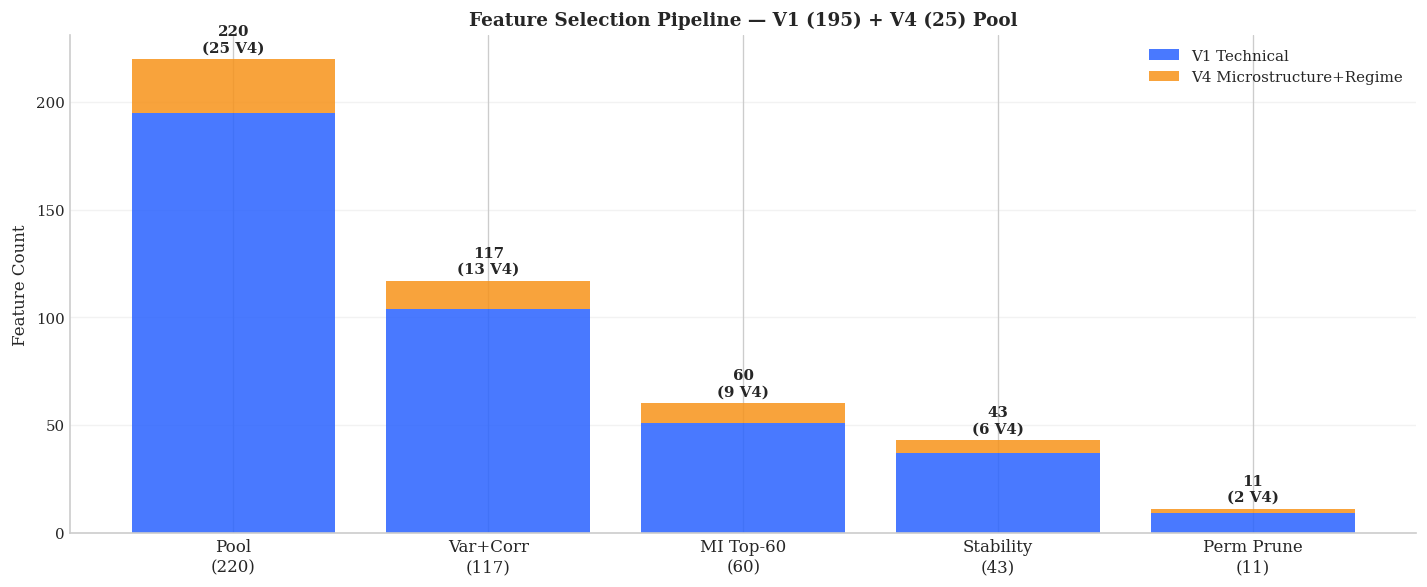

In [29]:
# ── Pipeline summary ──────────────────────────────────────────────────────────
print('FEATURE SELECTION PIPELINE SUMMARY')
print('─' * 55)
print(f'Stage 0 (Pool):      {len(ALL_FEATURE_COLS):>4}  ({len(V1_FEATURE_COLS)} V1 + {len(V4_FEATURE_COLS)} V4)')
print(f'Stage 1 (Filter):    {len(stage1):>4}')
print(f'Stage 2 (MI Rank):   {len(stage2):>4}  ({n_v4_s2} V4)')
print(f'Stage 3 (Stability): {len(stage3):>4}  ({len(v4_in_s3)} V4)')
print(f'Stage 4 (Prune):     {len(SELECTED_FEATURES):>4}  ({len(v4_in_s4)} V4 survived)')
print(f'\nFinal feature set ({len(SELECTED_FEATURES)} features):')
for i, f in enumerate(SELECTED_FEATURES):
    tag = '[V4]' if f in V4_FEATURE_COLS else '    '
    print(f'  {i+1:>2}. {tag} {f}')

# ── Funnel chart ──────────────────────────────────────────────────────────────
from hmats.viz.plots import plot_feature_group_pie, save_fig

stage_labels = [
    f'Pool\n({len(ALL_FEATURE_COLS)})',
    f'Var+Corr\n({len(stage1)})',
    f'MI Top-60\n({len(stage2)})',
    f'Stability\n({len(stage3)})',
    f'Perm Prune\n({len(SELECTED_FEATURES)})',
]
counts    = [len(ALL_FEATURE_COLS), len(stage1), len(stage2), len(stage3), len(SELECTED_FEATURES)]
v4_counts = [len(V4_FEATURE_COLS), len([f for f in stage1 if f in V4_FEATURE_COLS]),
             n_v4_s2, len(v4_in_s3), len(v4_in_s4)]
v1_counts = [c - v for c, v in zip(counts, v4_counts)]

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(stage_labels))
ax.bar(x, v1_counts, color=BLUE,  alpha=0.85, label='V1 Technical')
ax.bar(x, v4_counts, bottom=v1_counts, color=ACCENT, alpha=0.85, label='V4 Microstructure+Regime')
for xi, (c, v) in enumerate(zip(counts, v4_counts)):
    ax.text(xi, c + max(counts) * 0.01, f'{c}\n({v} V4)',
            ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(stage_labels, fontsize=10)
ax.set_ylabel('Feature Count')
ax.set_title(
    f'Feature Selection Pipeline — V1 ({len(V1_FEATURE_COLS)}) + V4 ({len(V4_FEATURE_COLS)}) Pool',
    fontweight='bold',
)
ax.legend()
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()
save_fig(fig, ARTS_DIR / '00_pipeline_funnel.png')
plt.show()


In [30]:
# Which V4 features made it through?
v4_selected = [f for f in SELECTED_FEATURES if f in V4_FEATURE_COLS]
v1_selected = [f for f in SELECTED_FEATURES if f in V1_FEATURE_COLS]
print(f'Selected features breakdown:')
print(f'  V1: {len(v1_selected)} / {len(V1_FEATURE_COLS)}')
print(f'  V4: {len(v4_selected)} / {len(V4_FEATURE_COLS)}  ← microstructure + regime dials')
if v4_selected:
    print(f'  V4 survivors: {v4_selected}')
else:
    print('  No V4 features survived selection (consider expanding V4 pool).')


Selected features breakdown:
  V1: 9 / 195
  V4: 2 / 25  ← microstructure + regime dials
  V4 survivors: ['close_vs_true_vwap', 'hurst_24h']


---
## Phase 2 — Walk-Forward Optimization (4 Schemes)

Identical to v5. Probabilities generated for full OOS period.


In [31]:
print('=' * 65)
print('PHASE 2 — WALK-FORWARD OPTIMIZATION')
print('=' * 65)

WFO_SCHEMES = {
    'EXP': {'name': 'Expanding (All History)', 'train_bars': None,  'color': BLUE},
    'L2Y': {'name': '2-Year Sliding',          'train_bars': 17520, 'color': ACCENT},
    'M1Y': {'name': '1-Year Sliding',          'train_bars': 8760,  'color': GREEN},
    'S3M': {'name': '3-Month Sliding',         'train_bars': 2160,  'color': RED},
}

BASE_LGBM_PARAMS = dict(
    num_leaves=31, max_depth=6, learning_rate=0.05,
    colsample_bytree=0.7, min_child_samples=50, subsample=0.7,
    reg_alpha=0.1, reg_lambda=1.0, n_estimators=500,
)

oos_df = merged[oos_mask].copy()
print(f'OOS period : {oos_df.index.min().date()} → {oos_df.index.max().date()}')
print(f'OOS bars   : {len(oos_df):,}')
print(f'Features   : {len(SELECTED_FEATURES)}')
print(f'\nWFO schemes:')
for sk, sc in WFO_SCHEMES.items():
    tb = f'{sc["train_bars"]:,} bars' if sc['train_bars'] else 'all past data'
    print(f'  {sk}: {sc["name"]:<28}  train={tb}')

PHASE 2 — WALK-FORWARD OPTIMIZATION
OOS period : 2024-01-01 → 2026-05-16
OOS bars   : 20,785
Features   : 11

WFO schemes:
  EXP: Expanding (All History)       train=all past data
  L2Y: 2-Year Sliding                train=17,520 bars
  M1Y: 1-Year Sliding                train=8,760 bars
  S3M: 3-Month Sliding               train=2,160 bars


In [32]:
def run_wfo(
    scheme_key: str,
    lgbm_params: dict = None,
    verbose: bool = True,
) -> pd.Series:
    """Walk-forward optimization for one training-window scheme.

    Returns OOS probability series indexed by timestamp.
    """
    if lgbm_params is None:
        lgbm_params = BASE_LGBM_PARAMS
    scheme = WFO_SCHEMES[scheme_key]

    n_oos     = len(oos_df)
    probs_all = np.full(n_oos, np.nan)
    n_fits    = 0

    step = 0
    while step * STEP_SIZE < n_oos:
        t0_pos = step * STEP_SIZE
        t1_pos = min((step + 1) * STEP_SIZE, n_oos)

        # Absolute index in merged for the first test bar
        first_test_ts = oos_df.index[t0_pos]
        abs_test_start = merged.index.searchsorted(first_test_ts)

        train_end_abs = abs_test_start - EMBARGO
        if train_end_abs < 300:
            step += 1
            continue

        if scheme['train_bars'] is None:
            train_start_abs = 0
        else:
            train_start_abs = max(0, train_end_abs - scheme['train_bars'])

        train_slice = merged.iloc[train_start_abs:train_end_abs]
        if len(train_slice) < 300:
            step += 1
            continue

        val_n = max(100, int(len(train_slice) * VAL_FRAC))
        tr = train_slice.iloc[:-val_n]
        va = train_slice.iloc[-val_n:]

        if tr[LABEL_COL].nunique() < 2 or va[LABEL_COL].nunique() < 2:
            step += 1
            continue

        X_tr = tr[SELECTED_FEATURES].fillna(0).values
        y_tr = tr[LABEL_COL].values
        X_va = va[SELECTED_FEATURES].fillna(0).values
        y_va = va[LABEL_COL].values

        model = lgb.LGBMClassifier(
            **lgbm_params, verbose=-1, random_state=42, n_jobs=-1
        )
        model.fit(
            X_tr, y_tr, eval_set=[(X_va, y_va)],
            callbacks=[lgb.early_stopping(30, verbose=False)],
        )

        X_test = oos_df.iloc[t0_pos:t1_pos][SELECTED_FEATURES].fillna(0).values
        probs  = model.predict_proba(X_test)[:, 1]
        probs_all[t0_pos:t1_pos] = probs
        n_fits += 1
        step   += 1

    if verbose:
        print(f'  [{scheme_key}] {scheme["name"]}: {n_fits} WFO fits')
    return pd.Series(probs_all, index=oos_df.index, name=scheme_key)

In [33]:
wfo_probs = {}
t_all = time.time()

for sk in WFO_SCHEMES:
    print(f'\n{"─"*60}')
    print(f'Running {sk}: {WFO_SCHEMES[sk]["name"]}')
    probs = run_wfo(sk)
    wfo_probs[sk] = probs

elapsed = time.time() - t_all
print(f'\nAll 4 WFO schemes done in {elapsed/60:.1f} min')


────────────────────────────────────────────────────────────
Running EXP: Expanding (All History)
  [EXP] Expanding (All History): 29 WFO fits

────────────────────────────────────────────────────────────
Running L2Y: 2-Year Sliding
  [L2Y] 2-Year Sliding: 29 WFO fits

────────────────────────────────────────────────────────────
Running M1Y: 1-Year Sliding
  [M1Y] 1-Year Sliding: 29 WFO fits

────────────────────────────────────────────────────────────
Running S3M: 3-Month Sliding
  [S3M] 3-Month Sliding: 29 WFO fits

All 4 WFO schemes done in 0.5 min


In [34]:
# ── ATH-anchored display window ───────────────────────────────────────────────
# The backtest is displayed starting from the FIRST bar where BTC close reached
# or exceeded the last OOS bar's closing price (the "today's price" level).
# Example: if OOS ends at $74k, find the first ever bar where BTC hit $74k —
# that is when we "could have entered" at today's price. Prevents the chart from
# showing the boring accumulation period before the ATH leg.
_oos_end_price = oos_df['close'].iloc[-1]
_ath_mask = merged['close'] >= _oos_end_price
if _ath_mask.any():
    ATH_START = merged[_ath_mask].index[0]
else:
    ATH_START = oos_df.index[0]  # fallback: show full OOS

# Offset into OOS array
_ath_offset = oos_df.index.searchsorted(ATH_START)
oos_ath     = oos_df.iloc[_ath_offset:].copy()
oos_index_ath = oos_ath.index

print(f'Last OOS close:  ${_oos_end_price:>10,.0f}')
print(f'ATH_START:       {ATH_START.date()}  (OOS bar {_ath_offset} / {len(oos_df)})')
print(f'ATH window:      {len(oos_ath):,} bars  '
      f'({oos_ath.index[0].date()} → {oos_ath.index[-1].date()})')


Last OOS close:  $    79,112
ATH_START:       2024-11-10  (OOS bar 7540 / 20785)
ATH window:      13,245 bars  (2024-11-10 → 2026-05-16)


In [35]:
# ── S&P 500 benchmark (SPY) ───────────────────────────────────────────────────
import yfinance as yf

try:
    _start_str = oos_ath.index[0].strftime('%Y-%m-%d')
    _end_str   = (oos_ath.index[-1] + pd.Timedelta('2D')).strftime('%Y-%m-%d')
    _spy_raw   = yf.download('SPY', start=_start_str, end=_end_str,
                              interval='1d', progress=False, auto_adjust=True)
    if isinstance(_spy_raw.columns, pd.MultiIndex):
        _spy_raw.columns = _spy_raw.columns.get_level_values(0)
    if len(_spy_raw) > 0:
        _spy_close = _spy_raw['Close'].squeeze()
        _spy_close.index = pd.to_datetime(_spy_close.index).tz_localize(None)
        _spy_h = _spy_close.reindex(oos_index_ath, method='ffill').ffill().bfill()
        sp500_pct = (_spy_h / _spy_h.iloc[0] - 1) * 100
        print(f'SPY: {len(_spy_raw)} daily bars → resampled to {len(sp500_pct):,} hourly')
        print(f'SPY ATH-window return: {sp500_pct.iloc[-1]:+.1f}%')
    else:
        sp500_pct = None
        print('SPY: empty response — no S&P500 benchmark')
except Exception as e:
    sp500_pct = None
    print(f'SPY download failed: {e}')

# ── Buy & Hold reference lines ────────────────────────────────────────────────
# Full OOS (for metrics)
bh_eq = oos_df['close'].values / oos_df['close'].iloc[0]
# ATH-window % return (for charts — starts at 0%)
bh_pct = (oos_ath['close'].values / oos_ath['close'].iloc[0] - 1) * 100
print(f'BTC B&H over ATH window: {bh_pct[-1]:+.1f}%')


SPY: 378 daily bars → resampled to 13,245 hourly
SPY ATH-window return: +25.7%
BTC B&H over ATH window: -0.0%


In [36]:
y_oos = oos_df[LABEL_COL].values


def _adaptive_thresholds(probs_arr,
                          adapt_window=ADAPT_WINDOW,
                          long_pct=LONG_PCT, short_pct=SHORT_PCT,
                          long_floor=LONG_FLOOR, short_ceil=SHORT_CEIL):
    """Precompute bar-by-bar adaptive thresholds via rolling quantile.

    At bar i: long_thr[i]  = max(long_floor,  quantile(probs[i-W:i], long_pct/100))
              short_thr[i] = min(short_ceil, quantile(probs[i-W:i], short_pct/100))
    Falls back to LONG_THRESHOLD / SHORT_THRESHOLD until enough history.
    """
    prob_s     = pd.Series(probs_arr)
    long_arr   = prob_s.rolling(adapt_window, min_periods=48).quantile(long_pct  / 100)
    short_arr  = prob_s.rolling(adapt_window, min_periods=48).quantile(short_pct / 100)
    long_arr   = np.maximum(long_arr.fillna(LONG_THRESHOLD).values,  long_floor)
    short_arr  = np.minimum(short_arr.fillna(SHORT_THRESHOLD).values, short_ceil)
    return long_arr, short_arr


def _equity_bidir(
    probs_arr,
    long_thr=LONG_THRESHOLD,    # used only when adaptive=False or as floor
    short_thr=SHORT_THRESHOLD,
    entry_atr_mult=DEFAULT_ENTRY_ATR,
    sl_mult=DEFAULT_SL_MULT,
    tp_mult=DEFAULT_TP_MULT,
    max_hold=DEFAULT_MAX_HOLD,
    cooldown_bars=DEFAULT_COOLDOWN,
    adaptive=True,
):
    """Long + Short ATR-stop equity from P(Up) array.

    Long  when probs > long_thr  (high conviction up).
    Short when probs < short_thr (high conviction NOT-up).
    Neutral zone [short_thr, long_thr]: flat.
    """
    n         = len(oos_df)
    close_arr = oos_df['close'].values
    high_arr  = oos_df['high'].values
    low_arr   = oos_df['low'].values
    atr_arr   = oos_df['atr_14_pct'].values

    # Adaptive thresholds: bar-by-bar rolling quantile
    if adaptive:
        long_thr_arr, short_thr_arr = _adaptive_thresholds(probs_arr)
    else:
        long_thr_arr  = np.full(n, long_thr)
        short_thr_arr = np.full(n, short_thr)

    equity_arr      = np.ones(n)
    cur_eq          = 1.0
    in_pos          = False
    direction       = None        # 'long' or 'short'
    pos_eq          = 1.0
    entry_px        = sl_px = tp_px = 0.0
    entry_bar       = hold_count = cooldown_count = 0
    funding_accrued = 0.0
    pending         = None        # ('long'|'short', lim_px, sl_px, tp_px)

    for i in range(n):
        lo = low_arr[i]; hi = high_arr[i]; px = close_arr[i]

        if in_pos:
            hold_count += 1
            # Funding per bar (hourly): short receives SHORT_FUNDING_H, long pays SPOT_FUNDING_H=0
            funding_accrued += SHORT_FUNDING_H if direction == 'short' else SPOT_FUNDING_H

            # Mark-to-market
            if direction == 'long':
                equity_arr[i] = pos_eq * px / entry_px
            else:
                equity_arr[i] = pos_eq * (1.0 + (entry_px - px) / entry_px)

            exited = False; exit_px = 0.0; reason = ''
            if direction == 'long':
                if   lo <= sl_px:            exit_px = sl_px; exited = True; reason = 'sl'
                elif hi >= tp_px:            exit_px = tp_px; exited = True; reason = 'tp'
                elif hold_count >= max_hold: exit_px = px;    exited = True; reason = 'timeout'
            else:  # short: SL above, TP below
                if   hi >= sl_px:            exit_px = sl_px; exited = True; reason = 'sl'
                elif lo <= tp_px:            exit_px = tp_px; exited = True; reason = 'tp'
                elif hold_count >= max_hold: exit_px = px;    exited = True; reason = 'timeout'

            if exited:
                if direction == 'long':
                    gross_ret = (exit_px - entry_px) / entry_px
                else:
                    gross_ret = (entry_px - exit_px) / entry_px
                net_ret = gross_ret + funding_accrued
                cur_eq  = pos_eq * (1.0 + net_ret)
                equity_arr[i] = cur_eq
                in_pos = False; cooldown_count = cooldown_bars; funding_accrued = 0.0

        elif pending is not None:
            dir_, lim_px, p_sl, p_tp = pending
            if dir_ == 'long':
                entry_px = lim_px if lo <= lim_px + BUFFER else px
            else:
                entry_px = lim_px if hi >= lim_px - BUFFER else px
            sl_px = p_sl; tp_px = p_tp
            direction = dir_
            in_pos = True; pos_eq = cur_eq; entry_bar = i
            hold_count = 0; funding_accrued = 0.0; pending = None
            equity_arr[i] = cur_eq

        elif cooldown_count > 0:
            cooldown_count -= 1; equity_arr[i] = cur_eq

        elif not np.isnan(probs_arr[i]) and i + 1 < n:
            atr  = atr_arr[i]
            lthr = long_thr_arr[i]
            sthr = short_thr_arr[i]
            if probs_arr[i] > lthr:
                pending = (
                    'long',
                    px * (1.0 - entry_atr_mult * atr),
                    px * (1.0 - sl_mult * atr),
                    px * (1.0 + tp_mult * atr),
                )
            elif probs_arr[i] < sthr:
                pending = (
                    'short',
                    px * (1.0 + entry_atr_mult * atr),
                    px * (1.0 + sl_mult * atr),
                    px * (1.0 - tp_mult * atr),
                )
            equity_arr[i] = cur_eq
        else:
            equity_arr[i] = cur_eq

    if in_pos:
        if direction == 'long':
            gross_ret = (close_arr[-1] - entry_px) / entry_px
        else:
            gross_ret = (entry_px - close_arr[-1]) / entry_px
        cur_eq = pos_eq * (1.0 + gross_ret + funding_accrued)
        equity_arr[-1] = cur_eq

    return equity_arr


# Backward-compat alias (used in grid search cell unchanged)
def _equity_from_probs(probs_arr, threshold=LONG_THRESHOLD, **kw):
    return _equity_bidir(probs_arr, long_thr=threshold, short_thr=1.0-threshold, **kw)


def _sharpe(eq):
    r = np.diff(np.log(np.maximum(eq, 1e-12)))
    return float(r.mean() / (r.std(ddof=1) + 1e-12) * np.sqrt(24 * 365))

def _maxdd(eq):
    pk = np.maximum.accumulate(eq)
    return float(((eq - pk) / (pk + 1e-12)).min())


wfo_metrics = {}
print(f'{"Scheme":<6}  {"Name":<28}  {"AUC":>6}  {"Sharpe":>7}  {"Return":>8}  {"MaxDD":>7}  {"Longs":>7}  {"Shorts":>7}')
print('─' * 90)

for sk, probs_s in wfo_probs.items():
    pa    = probs_s.values
    valid = ~np.isnan(pa)
    auc   = roc_auc_score(y_oos[valid], pa[valid]) if valid.sum() > 100 else 0.5
    eq    = _equity_bidir(pa)
    sh    = _sharpe(eq)
    dd    = _maxdd(eq)
    ret   = eq[-1] - 1
    n_long  = int((pa[valid] > LONG_THRESHOLD).sum())
    n_short = int((pa[valid] < SHORT_THRESHOLD).sum())
    wfo_metrics[sk] = {'auc': auc, 'sharpe': sh, 'total_ret': ret,
                       'maxdd': dd, 'equity': eq, 'n_long': n_long, 'n_short': n_short}
    print(f'{sk:<6}  {WFO_SCHEMES[sk]["name"]:<28}  {auc:.4f}  {sh:>7.3f}  '
          f'{ret:>+7.1%}  {dd:>7.1%}  {n_long:>7}  {n_short:>7}')

bh_eq = oos_df['close'].values / oos_df['close'].iloc[0]
print(f'\nBuy & Hold: return={bh_eq[-1]-1:+.1%}  sharpe={_sharpe(bh_eq):.3f}  maxdd={_maxdd(bh_eq):.1%}')

# v9: pick best by Sharpe (empirically M1Y dominates over AUC-maximiser EXP)
BEST_SCHEME = max(wfo_metrics, key=lambda k: wfo_metrics[k]['sharpe'])
print(f'\n★ Best WFO scheme by Sharpe: {BEST_SCHEME} ({WFO_SCHEMES[BEST_SCHEME]["name"]})')


Scheme  Name                             AUC   Sharpe    Return    MaxDD    Longs   Shorts
──────────────────────────────────────────────────────────────────────────────────────────
EXP     Expanding (All History)       0.5477   -0.043    -3.1%   -44.8%       78        4
L2Y     2-Year Sliding                0.5420   -0.144   -10.1%   -52.2%       50        0
M1Y     1-Year Sliding                0.5400    1.191  +126.5%   -28.5%       95       13
S3M     3-Month Sliding               0.5250    0.554   +40.3%   -31.0%      103       73

Buy & Hold: return=+86.3%  sharpe=0.542  maxdd=-50.1%

★ Best WFO scheme by Sharpe: M1Y (1-Year Sliding)


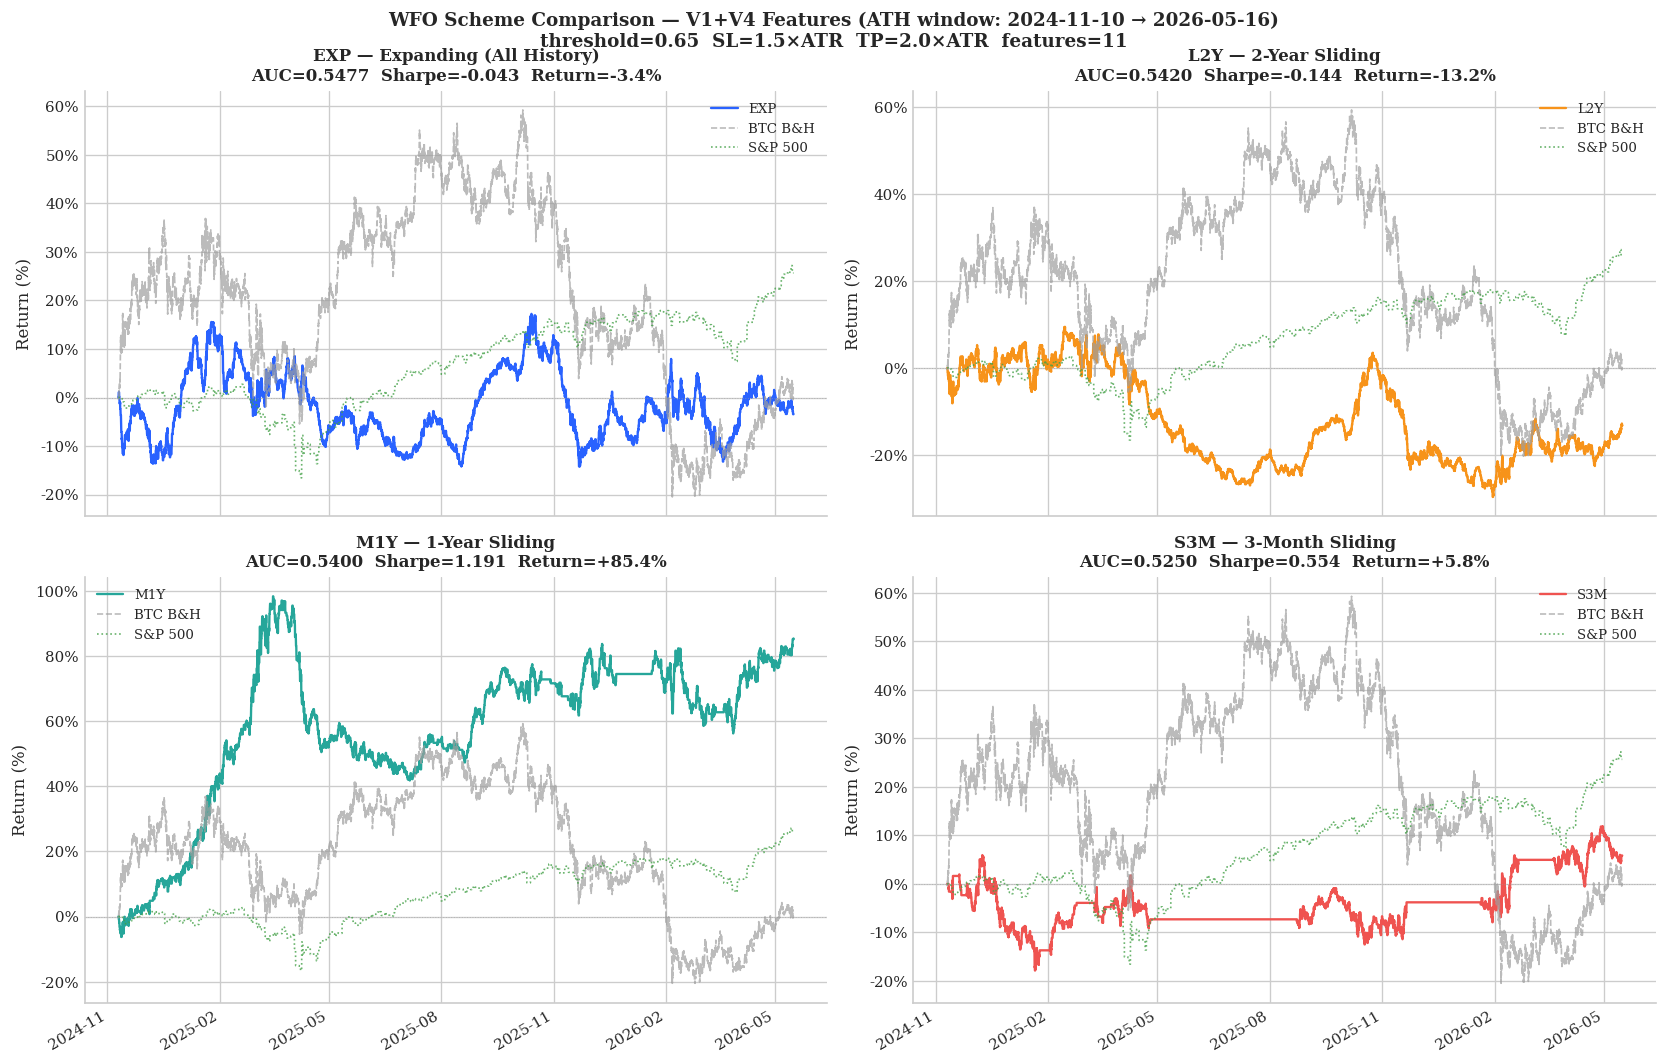

In [37]:
# ── WFO scheme comparison — ATH window, % returns ────────────────────────────
from hmats.viz.plots import plot_wfo_schemes, save_fig

# Compute ATH-trimmed metrics for display
# Re-base each equity slice so bar-0 = 1.0  →  chart starts at 0%
wfo_metrics_ath = {}
for sk, scheme in WFO_SCHEMES.items():
    pa_ath  = wfo_probs[sk][_ath_offset:]
    eq_full = _equity_from_probs(wfo_probs[sk].values)
    eq_ath  = eq_full[_ath_offset:]
    eq_ath  = eq_ath / eq_ath[0]   # re-base: bar-0 → 1.0 → 0% on chart
    m_full  = wfo_metrics[sk]
    wfo_metrics_ath[sk] = {
        'equity': eq_ath,
        'auc':    m_full['auc'],
        'sharpe': m_full['sharpe'],
        'total_ret': float(eq_ath[-1] - 1),
        'name':  scheme['name'],
        'color': scheme['color'],
    }

fig = plot_wfo_schemes(
    oos_index_ath, wfo_metrics_ath,
    bh_pct=bh_pct, sp500_pct=sp500_pct, ath_start=None,
)
fig.suptitle(
    f'WFO Scheme Comparison — V1+V4 Features (ATH window: {ATH_START.date()} → {oos_ath.index[-1].date()})\n'
    f'threshold={DEFAULT_THRESHOLD}  SL={DEFAULT_SL_MULT}×ATR  TP={DEFAULT_TP_MULT}×ATR  '
    f'features={len(SELECTED_FEATURES)}',
    fontweight='bold', fontsize=11,
)
save_fig(fig, ARTS_DIR / '01_wfo_scheme_comparison.png')
plt.show()


---
## Phase 3 — Parameter Grid Search


In [38]:
print('=' * 65)
print(f'PHASE 3 — GRID SEARCH ON BEST SCHEME: {BEST_SCHEME}')
print('=' * 65)

PARAM_GRID = {
    'num_leaves':        [15, 31],
    'max_depth':         [6, 8],
    'learning_rate':     [0.03, 0.05],
    'colsample_bytree':  [0.5, 0.7],
    'min_child_samples': [50],
    'subsample':         [0.7],
    'reg_alpha':         [0.1],
    'reg_lambda':        [1.0],
    'n_estimators':      [500],
}

keys   = list(PARAM_GRID.keys())
combos = list(itertools.product(*[PARAM_GRID[k] for k in keys]))
print(f'Grid combinations: {len(combos)}')

grid_results = []
t_grid = time.time()

for i, vals in enumerate(combos):
    params = dict(zip(keys, vals))
    if (i + 1) % 4 == 1:
        print(f'  Combo {i+1:>2}/{len(combos)}  ...  ({time.time()-t_grid:.0f}s elapsed)')

    probs_s  = run_wfo(BEST_SCHEME, lgbm_params=params, verbose=False)
    pa       = probs_s.values
    valid    = ~np.isnan(pa)
    if valid.sum() < 100:
        continue

    auc    = roc_auc_score(y_oos[valid], pa[valid])
    eq     = _equity_from_probs(pa)
    n_sig  = int((pa[valid] > DEFAULT_THRESHOLD).sum())
    grid_results.append({
        **params,
        'auc':       auc,
        'sharpe':    _sharpe(eq),
        'total_ret': eq[-1] - 1,
        'maxdd':     _maxdd(eq),
        'n_trades':  n_sig,
    })

grid_df = pd.DataFrame(grid_results).sort_values('auc', ascending=False).reset_index(drop=True)
print(f'\nGrid search done in {(time.time()-t_grid)/60:.1f} min')
print(f'\nTop 10 by OOS AUC:')
disp = ['num_leaves','max_depth','learning_rate','colsample_bytree','auc','sharpe','total_ret','n_trades']
print(grid_df[[c for c in disp if c in grid_df.columns]].head(10).to_string(index=False))

# Cast integer params back from DataFrame floats → ints before passing to LightGBM
_INT_KEYS = {'num_leaves', 'max_depth', 'min_child_samples', 'n_estimators'}
BEST_PARAMS = {
    k: int(grid_df.iloc[0][k]) if k in _INT_KEYS else float(grid_df.iloc[0][k])
    for k in keys
}
print(f'\n★ Best params: {BEST_PARAMS}')
print(f'  OOS AUC    : {grid_df.iloc[0]["auc"]:.4f}')
print(f'  OOS Sharpe : {grid_df.iloc[0]["sharpe"]:.3f}')
print(f'  OOS Return : {grid_df.iloc[0]["total_ret"]:+.2%}')

PHASE 3 — GRID SEARCH ON BEST SCHEME: M1Y
Grid combinations: 16
  Combo  1/16  ...  (0s elapsed)
  Combo  5/16  ...  (21s elapsed)
  Combo  9/16  ...  (49s elapsed)
  Combo 13/16  ...  (101s elapsed)

Grid search done in 2.7 min

Top 10 by OOS AUC:
 num_leaves  max_depth  learning_rate  colsample_bytree    auc  sharpe  total_ret  n_trades
         15          8         0.0500            0.7000 0.5437  1.0132     1.0706        93
         15          8         0.0300            0.7000 0.5436  0.7016     0.6518        61
         15          6         0.0300            0.5000 0.5429  0.8906     0.9111        50
         15          8         0.0500            0.5000 0.5426  0.5147     0.4559        61
         15          8         0.0300            0.5000 0.5421  0.9626     1.0113        77
         15          6         0.0300            0.7000 0.5418  0.3205     0.2555        88
         15          6         0.0500            0.7000 0.5416  1.7412     2.4514       135
         15    

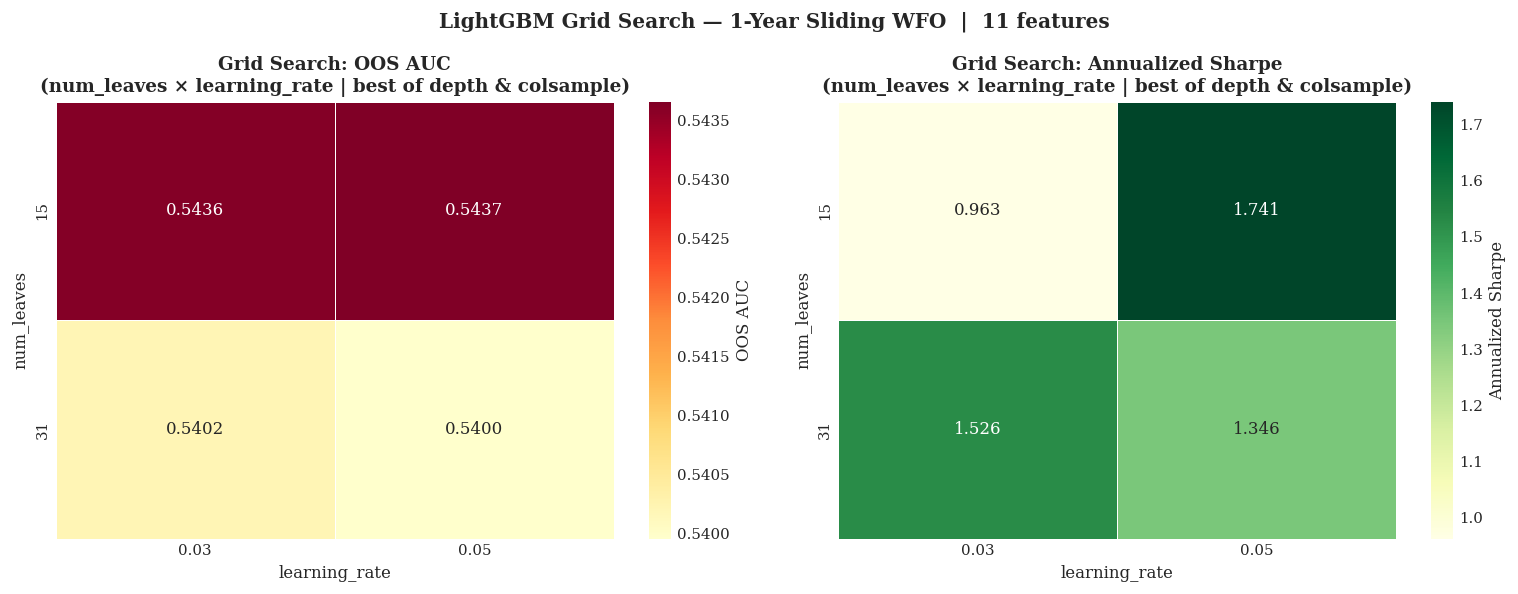

In [39]:
pivot_auc    = grid_df.pivot_table(index='num_leaves', columns='learning_rate',
                                   values='auc',    aggfunc='max')
pivot_sharpe = grid_df.pivot_table(index='num_leaves', columns='learning_rate',
                                   values='sharpe', aggfunc='max')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(pivot_auc,    ax=axes[0], annot=True, fmt='.4f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'OOS AUC'})
axes[0].set_title(
    f'Grid Search: OOS AUC\n'
    f'(num_leaves × learning_rate | best of depth & colsample)',
    fontweight='bold',
)
axes[0].set_xlabel('learning_rate'); axes[0].set_ylabel('num_leaves')

sns.heatmap(pivot_sharpe, ax=axes[1], annot=True, fmt='.3f', cmap='YlGn',
            linewidths=0.5, cbar_kws={'label': 'Annualized Sharpe'})
axes[1].set_title(
    f'Grid Search: Annualized Sharpe\n'
    f'(num_leaves × learning_rate | best of depth & colsample)',
    fontweight='bold',
)
axes[1].set_xlabel('learning_rate'); axes[1].set_ylabel('num_leaves')

fig.suptitle(
    f'LightGBM Grid Search — {WFO_SCHEMES[BEST_SCHEME]["name"]} WFO  |  {len(SELECTED_FEATURES)} features',
    fontweight='bold',
)
fig.tight_layout()
fig.savefig(ARTS_DIR / '02_grid_search_heatmap.png')
plt.show()

---
## Phase 4 — Backtesting with Best Params (Spot Fees)

Same as v5: long-only ATR-stop backtester with Binance Spot fees.
- Limit entry → maker (0% free)
- TP exit → maker (0% free)
- SL / timeout → taker (0.05%)


In [40]:
print('=' * 65)
print('PHASE 4 — BACKTESTING WITH BEST PARAMS')
print('=' * 65)

print(f'Re-running WFO ({BEST_SCHEME}) with best params...')
best_probs_s = run_wfo(BEST_SCHEME, lgbm_params=BEST_PARAMS)


def run_bidir_backtest(
    df_oos: pd.DataFrame,
    probs_series: pd.Series,
    long_thr: float = LONG_THRESHOLD,
    short_thr: float = SHORT_THRESHOLD,
    entry_atr_mult: float = DEFAULT_ENTRY_ATR,
    sl_mult: float = DEFAULT_SL_MULT,
    tp_mult: float = DEFAULT_TP_MULT,
    max_hold: int = DEFAULT_MAX_HOLD,
    cooldown_bars: int = DEFAULT_COOLDOWN,
    maker_fee: float = MAKER_FEE,
    spot_taker_fee: float = SPOT_TAKER_FEE,
    futures_taker_fee: float = FUTURES_TAKER_FEE,
    spot_funding_h: float = SPOT_FUNDING_H,
    short_funding_h: float = SHORT_FUNDING_H,
    adaptive: bool = True,
):
    """Long + Short ATR-stop backtester with perpetual futures fees and funding.

    Long  when P(Up) > long_thr  → limit buy entry below market
    Short when P(Up) < short_thr → limit sell entry above market

    Fee logic (perpetual):
      - Entry limit filled     → maker_fee
      - Entry market fill      → taker_fee
      - TP exit (limit)        → maker_fee
      - SL / timeout (market)  → taker_fee
      - Funding (per 1h bar): short receives short_funding_h, long: spot_funding_h=0
    """
    n         = len(df_oos)
    close_arr = df_oos['close'].values
    high_arr  = df_oos['high'].values
    low_arr   = df_oos['low'].values
    atr_arr   = df_oos['atr_14_pct'].values
    probs     = probs_series.reindex(df_oos.index).fillna(np.nan).values

    # Adaptive thresholds (rolling quantile over recent probability history)
    if adaptive:
        long_thr_arr, short_thr_arr = _adaptive_thresholds(probs)
    else:
        long_thr_arr  = np.full(n, long_thr)
        short_thr_arr = np.full(n, short_thr)

    equity_arr      = np.ones(n)
    cur_eq          = 1.0
    trade_log       = []
    in_pos          = False
    direction       = None
    pos_eq          = 1.0
    entry_px        = sl_px = tp_px = 0.0
    entry_bar       = hold_count = cooldown_count = 0
    entry_fee_paid  = 0.0
    funding_accrued = 0.0
    pending         = None

    for i in range(n):
        lo = low_arr[i]; hi = high_arr[i]; px = close_arr[i]

        if in_pos:
            hold_count += 1
            # Per-bar funding: short receives, long is zero (spot has no funding)
            funding_accrued += short_funding_h if direction == 'short' else spot_funding_h

            if direction == 'long':
                equity_arr[i] = pos_eq * px / entry_px
            else:
                equity_arr[i] = pos_eq * (1.0 + (entry_px - px) / entry_px)

            exited = False; exit_px = 0.0; reason = ''; exit_fee = 0.0
            if direction == 'long':
                if   lo <= sl_px:            exit_px=sl_px; exited=True; reason='sl';      exit_fee=spot_taker_fee
                elif hi >= tp_px:            exit_px=tp_px; exited=True; reason='tp';      exit_fee=maker_fee
                elif hold_count >= max_hold: exit_px=px;    exited=True; reason='timeout'; exit_fee=spot_taker_fee
            else:
                if   hi >= sl_px:            exit_px=sl_px; exited=True; reason='sl';      exit_fee=futures_taker_fee
                elif lo <= tp_px:            exit_px=tp_px; exited=True; reason='tp';      exit_fee=maker_fee
                elif hold_count >= max_hold: exit_px=px;    exited=True; reason='timeout'; exit_fee=futures_taker_fee

            if exited:
                if direction == 'long':
                    gross_ret = (exit_px - entry_px) / entry_px
                else:
                    gross_ret = (entry_px - exit_px) / entry_px
                net_ret = gross_ret - entry_fee_paid - exit_fee + funding_accrued
                cur_eq  = pos_eq * (1.0 + net_ret)
                equity_arr[i] = cur_eq
                trade_log.append({
                    'entry_bar': entry_bar, 'exit_bar': i,
                    'entry_time': df_oos.index[entry_bar],
                    'exit_time':  df_oos.index[i],
                    'direction':  direction,
                    'entry_px':   float(entry_px), 'exit_px': float(exit_px),
                    'gross_pct':  float(gross_ret * 100),
                    'funding_pct':float(funding_accrued * 100),
                    'pnl_pct':    float(net_ret * 100),
                    'reason':     reason, 'hold_bars': hold_count,
                })
                in_pos = False; cooldown_count = cooldown_bars; funding_accrued = 0.0

        elif pending is not None:
            dir_, lim_px, p_sl, p_tp = pending
            if dir_ == 'long':
                if lo <= lim_px + BUFFER: entry_px = lim_px; entry_fee_paid = maker_fee
                else:                     entry_px = px;     entry_fee_paid = spot_taker_fee
            else:
                if hi >= lim_px - BUFFER: entry_px = lim_px; entry_fee_paid = maker_fee
                else:                     entry_px = px;     entry_fee_paid = futures_taker_fee
            sl_px = p_sl; tp_px = p_tp; direction = dir_
            in_pos = True; pos_eq = cur_eq; entry_bar = i
            hold_count = 0; funding_accrued = 0.0; pending = None
            equity_arr[i] = cur_eq

        elif cooldown_count > 0:
            cooldown_count -= 1; equity_arr[i] = cur_eq

        elif not np.isnan(probs[i]) and i + 1 < n:
            atr  = atr_arr[i]
            lthr = long_thr_arr[i]
            sthr = short_thr_arr[i]
            if probs[i] > lthr:
                pending = ('long',
                           px*(1-entry_atr_mult*atr), px*(1-sl_mult*atr), px*(1+tp_mult*atr))
            elif probs[i] < sthr:
                pending = ('short',
                           px*(1+entry_atr_mult*atr), px*(1+sl_mult*atr), px*(1-tp_mult*atr))
            equity_arr[i] = cur_eq
        else:
            equity_arr[i] = cur_eq

    if in_pos:
        if direction == 'long': gross_ret = (close_arr[-1] - entry_px) / entry_px
        else:                   gross_ret = (entry_px - close_arr[-1]) / entry_px
        eod_fee = futures_taker_fee if direction == 'short' else spot_taker_fee
        net_ret = gross_ret - entry_fee_paid - eod_fee + funding_accrued
        cur_eq  = pos_eq * (1.0 + net_ret)
        equity_arr[-1] = cur_eq
        trade_log.append({
            'entry_bar': entry_bar, 'exit_bar': n-1,
            'entry_time': df_oos.index[entry_bar], 'exit_time': df_oos.index[-1],
            'direction': direction, 'entry_px': float(entry_px), 'exit_px': float(close_arr[-1]),
            'gross_pct': float(gross_ret*100), 'funding_pct': float(funding_accrued*100),
            'pnl_pct': float(net_ret*100), 'reason': 'eod', 'hold_bars': hold_count,
        })

    return equity_arr, pd.DataFrame(trade_log)


# Run: long-only baseline vs long+short, with and without fees
eq_long_only, tdf_long  = run_bidir_backtest(oos_df, best_probs_s,
                                              long_thr=LONG_THRESHOLD, short_thr=1.0,
                                              spot_funding_h=0.0, short_funding_h=0.0, adaptive=True)
eq_bidir,     tdf_bidir = run_bidir_backtest(oos_df, best_probs_s,
                                              adaptive=True)
# Alias for downstream cells
eq_055, tdf_055 = eq_bidir, tdf_bidir
eq_fee_055, tdf_fee_055 = eq_bidir, tdf_bidir   # bidir already includes fees

print(f'\n{"":22}  {"Trades":>7}  {"Longs":>6}  {"Shorts":>7}  {"WinRate":>8}  {"Return":>8}  {"Sharpe":>7}  {"MaxDD":>7}')
print('─' * 82)
for lbl, eq, tdf in [
    ('Long-only w/fees', eq_long_only, tdf_long),
    ('Long+Short w/fees+funding', eq_bidir, tdf_bidir),
]:
    wr    = (tdf['pnl_pct'] > 0).mean() if len(tdf) > 0 else 0.0
    n_l   = int((tdf['direction'] == 'long').sum())  if len(tdf) > 0 else 0
    n_s   = int((tdf['direction'] == 'short').sum()) if len(tdf) > 0 else 0
    print(f'{lbl:22}  {len(tdf):>7}  {n_l:>6}  {n_s:>7}  {wr:>8.1%}  '
          f'{eq[-1]-1:>+7.1%}  {_sharpe(eq):>7.3f}  {_maxdd(eq):>7.2%}')

# Show how threshold varied over OOS
long_thr_oos, short_thr_oos = _adaptive_thresholds(
    best_probs_s.reindex(oos_df.index).fillna(np.nan).values)
print(f'\nAdaptive threshold stats over OOS:')
print(f'  Long  thr — mean={long_thr_oos.mean():.3f}  min={long_thr_oos.min():.3f}  max={long_thr_oos.max():.3f}')
print(f'  Short thr — mean={short_thr_oos.mean():.3f}  min={short_thr_oos.min():.3f}  max={short_thr_oos.max():.3f}')

if len(tdf_bidir) > 0:
    shorts = tdf_bidir[tdf_bidir['direction']=='short']
    longs  = tdf_bidir[tdf_bidir['direction']=='long']
    print(f'\nBreakdown by direction:')
    for side, sub in [('Long', longs), ('Short', shorts)]:
        if len(sub):
            avg_fund = sub['funding_pct'].mean()
            wr_s = (sub['pnl_pct']>0).mean()
            print(f'  {side:6}: {len(sub):>4} trades  WR={wr_s:.1%}  '
                  f'avg_gross={sub["gross_pct"].mean():+.3f}%  '
                  f'avg_funding={avg_fund:+.4f}%  '
                  f'avg_net={sub["pnl_pct"].mean():+.3f}%')


PHASE 4 — BACKTESTING WITH BEST PARAMS
Re-running WFO (M1Y) with best params...
  [M1Y] 1-Year Sliding: 29 WFO fits

                         Trades   Longs   Shorts   WinRate    Return   Sharpe    MaxDD
──────────────────────────────────────────────────────────────────────────────────
Long-only w/fees           1095     635      460     44.1%   +15.5%    0.199  -47.15%
Long+Short w/fees+funding     1095     635      460     44.2%   +19.8%    0.248  -46.58%

Adaptive threshold stats over OOS:
  Long  thr — mean=0.546  min=0.530  max=0.650
  Short thr — mean=0.466  min=0.350  max=0.470

Breakdown by direction:
  Long  :  635 trades  WR=44.4%  avg_gross=+0.100%  avg_funding=+0.0000%  avg_net=+0.050%
  Short :  460 trades  WR=43.9%  avg_gross=+0.037%  avg_funding=+0.0078%  avg_net=-0.005%


In [41]:
# Long+short at a tighter threshold (0.68/0.32) for comparison
# Tighter floors — adaptive still applies on top
eq_060, tdf_060 = run_bidir_backtest(oos_df, best_probs_s,
                                     long_thr=0.56, short_thr=0.44,   # tighter floor/ceil
                                     adaptive=True)
eq_fee_060 = eq_060  # alias for downstream chart compat

print('Tighter threshold (0.68 / 0.32):')
wr = (tdf_060['pnl_pct']>0).mean() if len(tdf_060)>0 else 0
n_l = int((tdf_060['direction']=='long').sum())  if len(tdf_060)>0 else 0
n_s = int((tdf_060['direction']=='short').sum()) if len(tdf_060)>0 else 0
print(f'  Trades {len(tdf_060)} (L={n_l} S={n_s})  WR={wr:.1%}  '
      f'ret={eq_060[-1]-1:+.2%}  Sharpe={_sharpe(eq_060):.3f}  MaxDD={_maxdd(eq_060):.2%}')


Tighter threshold (0.68 / 0.32):
  Trades 1095 (L=635 S=460)  WR=44.2%  ret=+19.75%  Sharpe=0.248  MaxDD=-46.58%


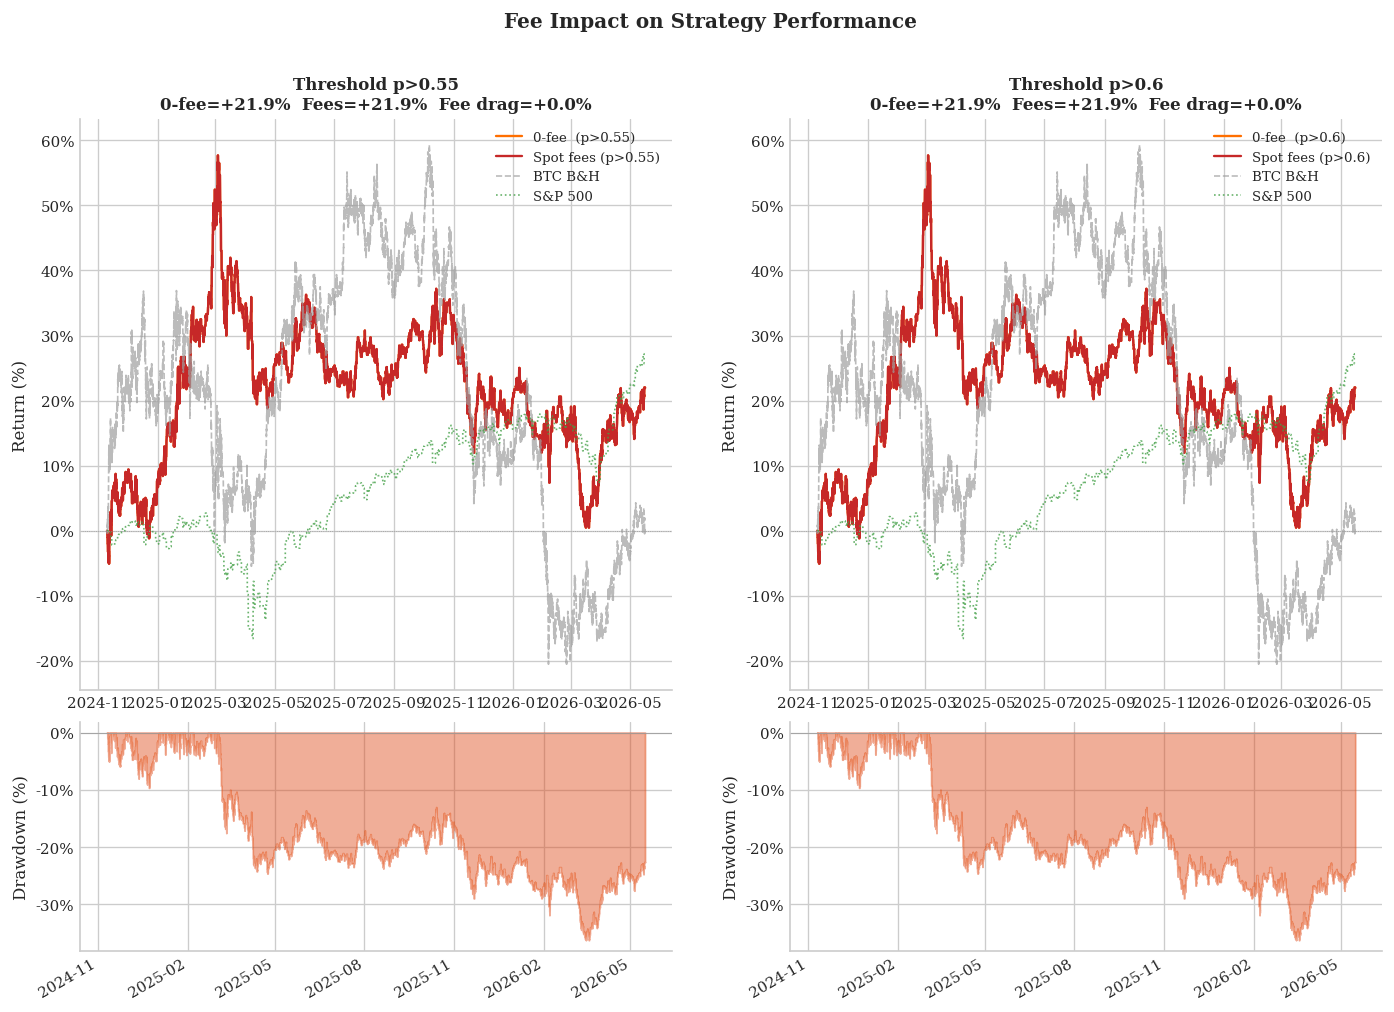

In [42]:
# ── Chart: 0-fee vs fee-adjusted equity overlay (2×2: thr 0.55 / 0.60) ───────
from hmats.viz.plots import plot_fee_comparison, save_fig

def _rebase(arr):
    a = arr[_ath_offset:]
    return a / a[0]

fig = plot_fee_comparison(
    oos_index_ath,
    eq_0fee       = _rebase(eq_055),
    eq_fee        = _rebase(eq_fee_055),
    threshold     = 0.55,
    eq_0fee_alt   = _rebase(eq_060),
    eq_fee_alt    = _rebase(eq_fee_060),
    threshold_alt = 0.60,
    bh_pct        = bh_pct,
    sp500_pct     = sp500_pct,
)
save_fig(fig, ARTS_DIR / '08_fee_comparison.png')
plt.show()


---
## Phase 5 — Visualizations


PHASE 5 — VISUALIZATIONS


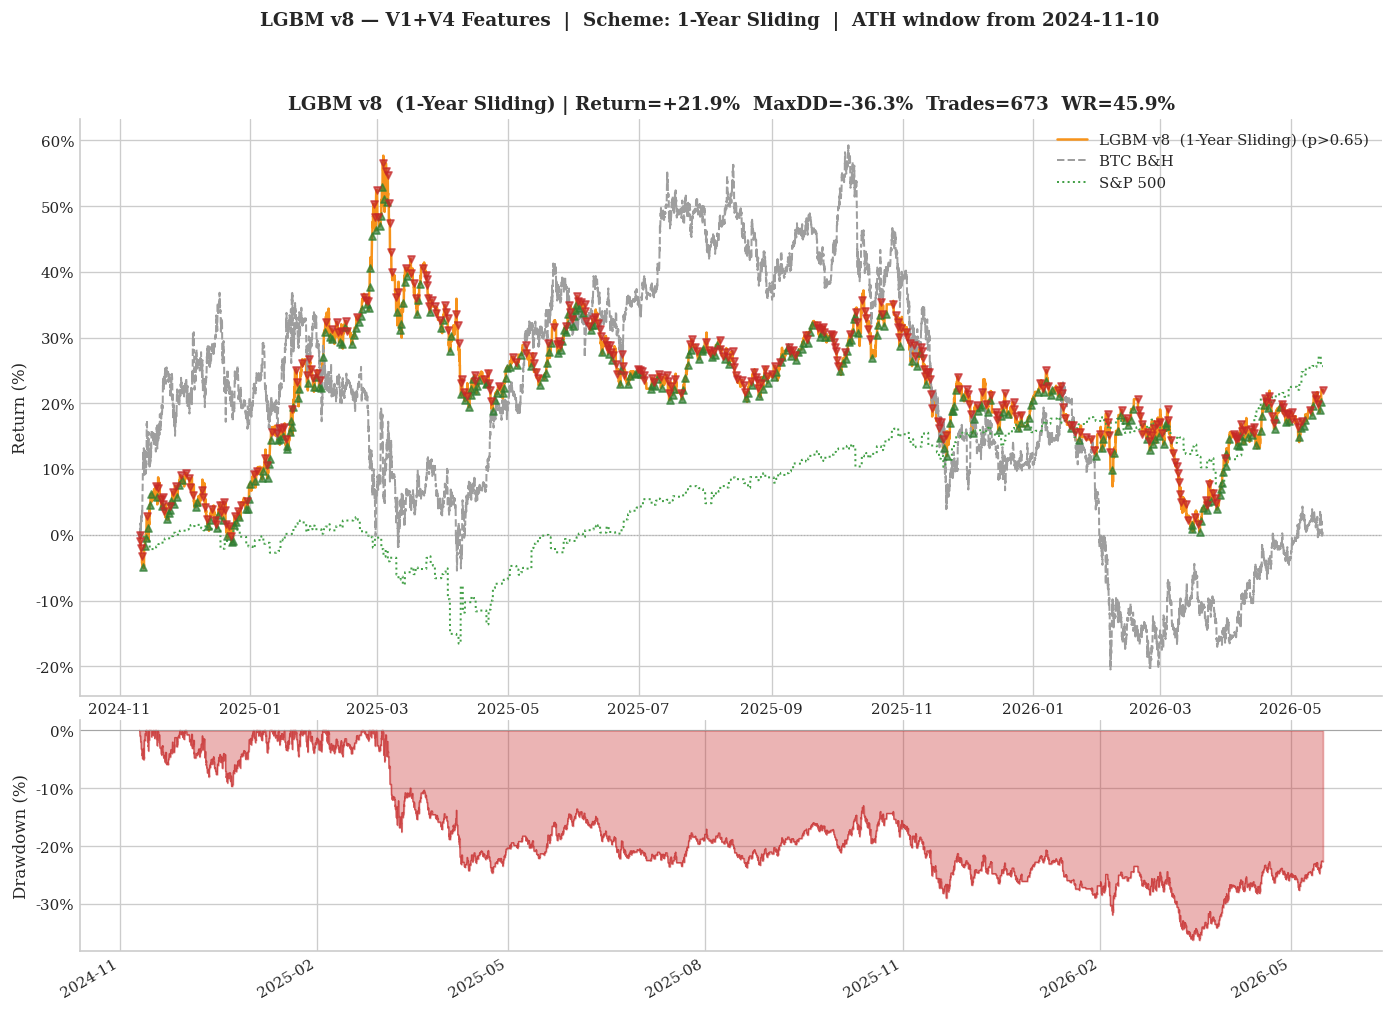

In [43]:
# ── Chart 1: Equity + Drawdown overlay with trade markers ─────────────────────
print('=' * 65)
print('PHASE 5 — VISUALIZATIONS')
print('=' * 65)
from hmats.viz.plots import plot_equity_drawdown, save_fig

eq_ath  = eq_055[_ath_offset:]; eq_ath = eq_ath / eq_ath[0]
tdf_ath = tdf_055[tdf_055['entry_time'] >= oos_index_ath[0]].copy() if len(tdf_055) > 0 else pd.DataFrame()

fig = plot_equity_drawdown(
    oos_index_ath, eq_ath, tdf_ath,
    bh_pct    = bh_pct,
    sp500_pct = sp500_pct,
    label     = f'LGBM v8  ({WFO_SCHEMES[BEST_SCHEME]["name"]})',
    threshold = DEFAULT_THRESHOLD,
    color     = ACCENT,
)
fig.suptitle(
    f'LGBM v8 — V1+V4 Features  |  Scheme: {WFO_SCHEMES[BEST_SCHEME]["name"]}  '
    f'|  ATH window from {ATH_START.date()}',
    fontsize=11, fontweight='bold',
)
save_fig(fig, ARTS_DIR / '03_equity_drawdown.png')
plt.show()


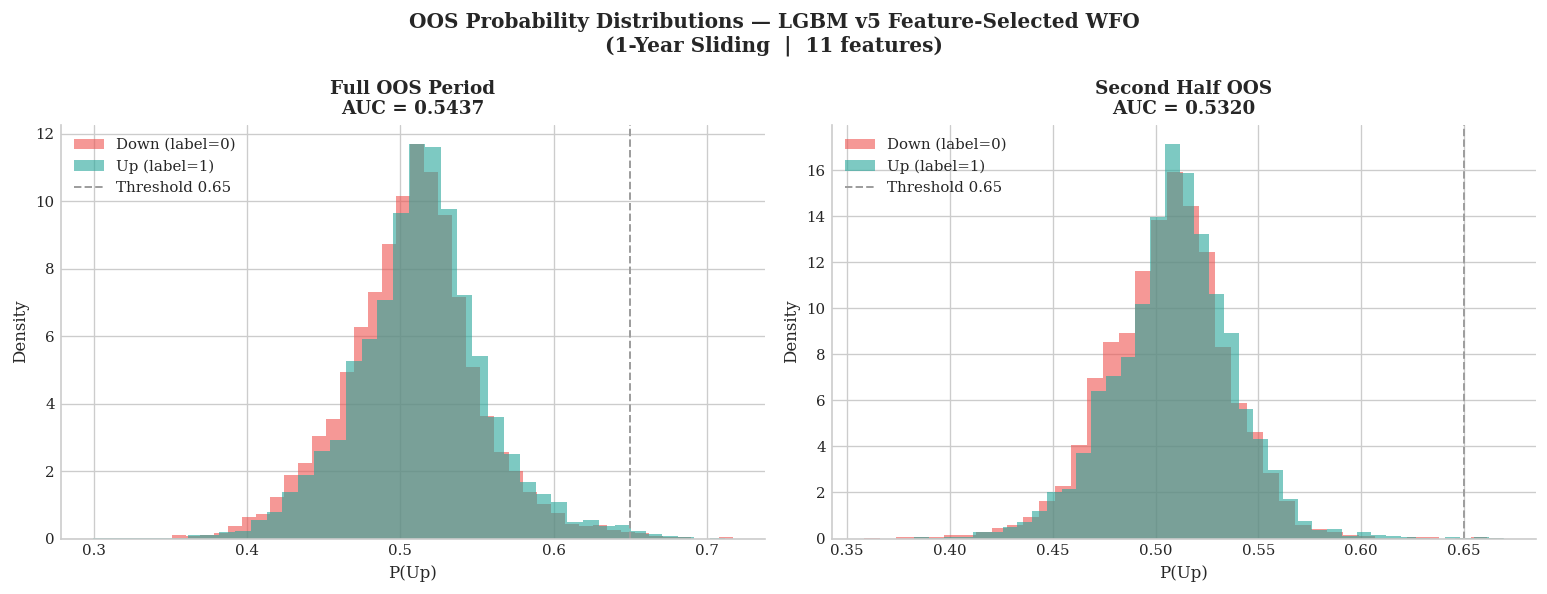

In [44]:
# ── Chart 2: Probability distributions — class 0 vs class 1 ──────────────────
pa    = best_probs_s.values
valid = ~np.isnan(pa)
n_oos_bars = len(y_oos)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

half = n_oos_bars // 2
splits = [
    ('Full OOS Period', valid),
    ('Second Half OOS', np.concatenate([np.zeros(half, bool), np.ones(n_oos_bars - half, bool)]) & valid),
]

for ax, (title, mask) in zip(axes, splits):
    y_sub = y_oos[mask]
    p_sub = pa[mask]
    if len(p_sub) < 10 or len(np.unique(y_sub)) < 2:
        ax.set_title(f'{title}\n(insufficient data)')
        continue
    auc_sub = roc_auc_score(y_sub, p_sub)
    ax.hist(p_sub[y_sub == 0], bins=40, alpha=0.60, label='Down (label=0)',
            color=RED, density=True)
    ax.hist(p_sub[y_sub == 1], bins=40, alpha=0.60, label='Up (label=1)',
            color=GREEN, density=True)
    ax.axvline(DEFAULT_THRESHOLD, color=GREY, lw=1.2, ls='--',
               label=f'Threshold {DEFAULT_THRESHOLD}')
    ax.set_title(f'{title}\nAUC = {auc_sub:.4f}', fontweight='bold')
    ax.set_xlabel('P(Up)'); ax.set_ylabel('Density'); ax.legend()

fig.suptitle(
    f'OOS Probability Distributions — LGBM v5 Feature-Selected WFO\n'
    f'({WFO_SCHEMES[BEST_SCHEME]["name"]}  |  {len(SELECTED_FEATURES)} features)',
    fontweight='bold',
)
fig.tight_layout()
fig.savefig(ARTS_DIR / '04_probability_distributions.png')
plt.show()

Training final model for feature importance...
  Best iteration: 86


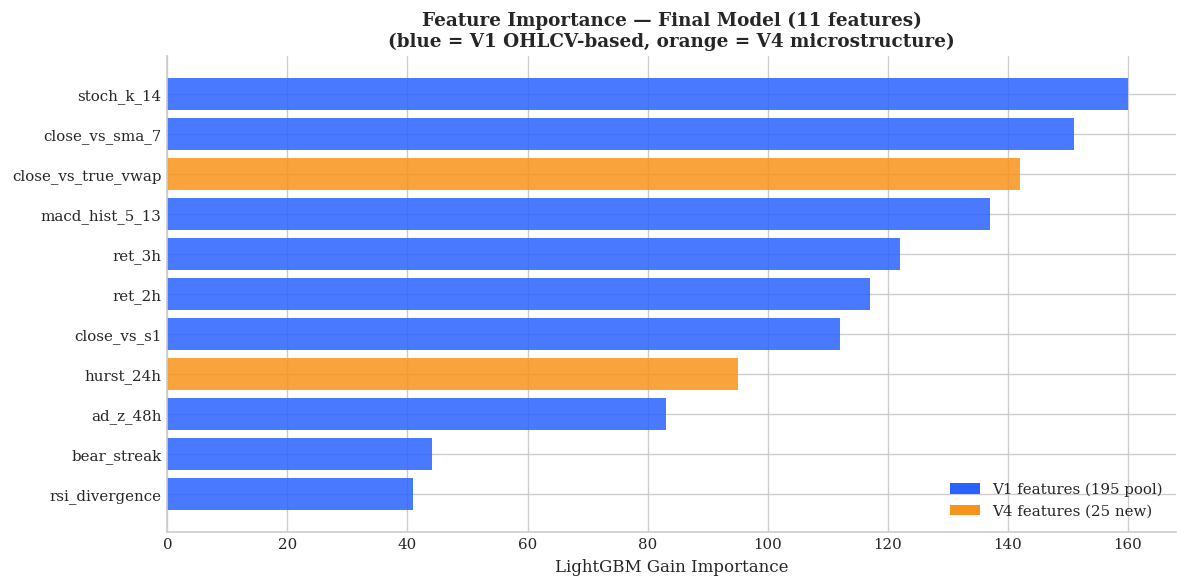

In [45]:
# ── Chart 3: Feature importance — train final model on all pre-OOS data ───────
print('Training final model for feature importance...')
train_full   = merged[~oos_mask]
val_n_final  = max(500, int(len(train_full) * 0.15))
X_tr_f = train_full.iloc[:-val_n_final][SELECTED_FEATURES].fillna(0).values
y_tr_f = train_full.iloc[:-val_n_final][LABEL_COL].values
X_va_f = train_full.iloc[-val_n_final:][SELECTED_FEATURES].fillna(0).values
y_va_f = train_full.iloc[-val_n_final:][LABEL_COL].values

final_model = lgb.LGBMClassifier(
    **{k: BEST_PARAMS[k] for k in keys},
    verbose=-1, random_state=42, n_jobs=-1,
)
final_model.fit(
    X_tr_f, y_tr_f, eval_set=[(X_va_f, y_va_f)],
    callbacks=[lgb.early_stopping(30, verbose=False)],
)
print(f'  Best iteration: {final_model.best_iteration_}')

lgb_imp = pd.DataFrame({
    'feature': SELECTED_FEATURES,
    'gain':    final_model.feature_importances_,
    'is_v4':   [f in V4_FEATURE_COLS for f in SELECTED_FEATURES],
}).sort_values('gain', ascending=False).reset_index(drop=True)

colors = [ACCENT if v4 else BLUE for v4 in lgb_imp['is_v4']]
fig, ax = plt.subplots(figsize=(10, max(5, len(lgb_imp) * 0.38)))
ax.barh(range(len(lgb_imp)), lgb_imp['gain'].values, color=colors, alpha=0.85)
ax.set_yticks(range(len(lgb_imp)))
ax.set_yticklabels(lgb_imp['feature'].values, fontsize=9)
ax.set_xlabel('LightGBM Gain Importance')
ax.set_title(
    f'Feature Importance — Final Model ({len(SELECTED_FEATURES)} features)\n'
    f'(blue = V1 OHLCV-based, orange = V4 microstructure)',
    fontweight='bold',
)
ax.invert_yaxis()
ax.legend(handles=[
    mpatches.Patch(facecolor=BLUE,  label=f'V1 features ({len(V1_FEATURE_COLS)} pool)'),
    mpatches.Patch(facecolor=ACCENT, label=f'V4 features ({len(V4_FEATURE_COLS)} new)'),
])
fig.tight_layout()
fig.savefig(ARTS_DIR / '05_feature_importance.png')
plt.show()

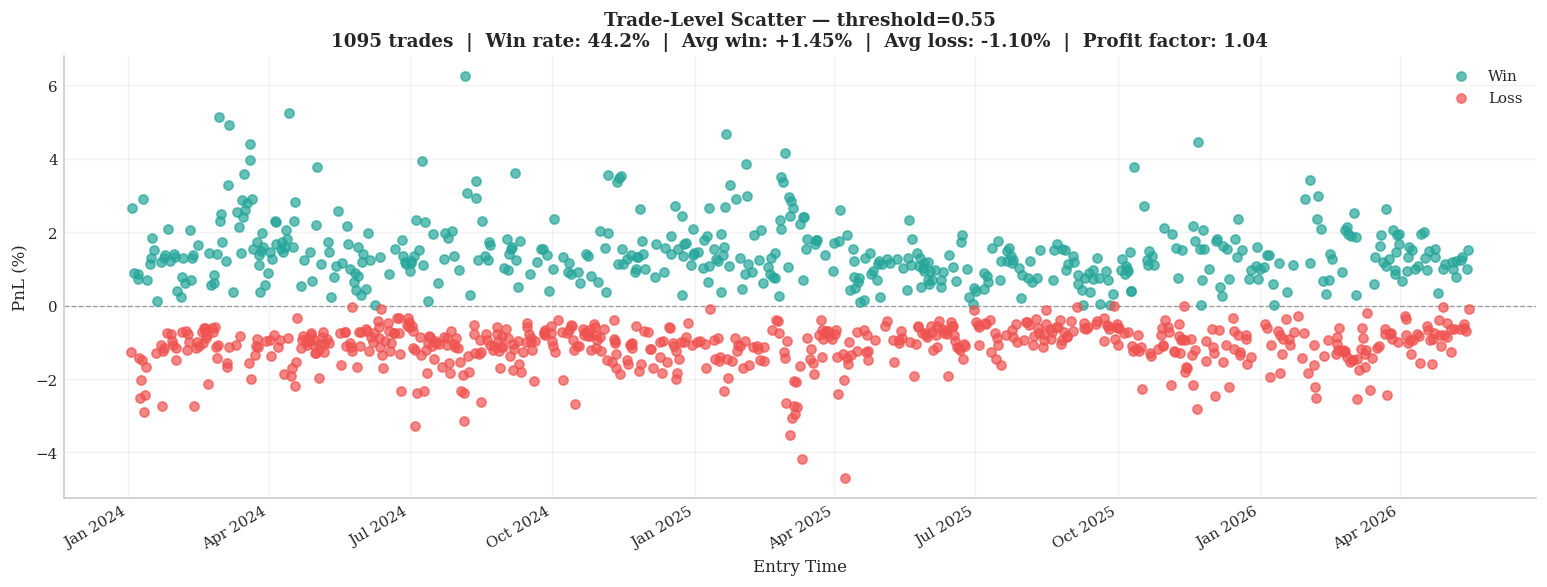

In [46]:
# ── Chart 4: Trade-level scatter ──────────────────────────────────────────────
if len(tdf_055) > 0:
    wins  = tdf_055[tdf_055['pnl_pct'] >  0]
    loses = tdf_055[tdf_055['pnl_pct'] <= 0]

    fig, ax = plt.subplots(figsize=(13, 5))
    ax.scatter(wins['entry_time'],  wins['pnl_pct'],
               color=GREEN, alpha=0.70, s=30, label='Win', zorder=3)
    ax.scatter(loses['entry_time'], loses['pnl_pct'],
               color=RED,   alpha=0.70, s=30, label='Loss', zorder=3)
    ax.axhline(0, color=GREY, lw=0.8, ls='--')
    wr = (tdf_055['pnl_pct'] > 0).mean()
    avg_win  = wins['pnl_pct'].mean()  if len(wins)  > 0 else 0.0
    avg_loss = loses['pnl_pct'].mean() if len(loses) > 0 else 0.0
    ax.set_xlabel('Entry Time'); ax.set_ylabel('PnL (%)')
    ax.set_title(
        f'Trade-Level Scatter — threshold=0.55\n'
        f'{len(tdf_055)} trades  |  Win rate: {wr:.1%}  '
        f'|  Avg win: {avg_win:+.2f}%  |  Avg loss: {avg_loss:+.2f}%  '
        f'|  Profit factor: {-wins["pnl_pct"].sum()/loses["pnl_pct"].sum():.2f}',
        fontweight='bold',
    )
    ax.legend()
    ax.grid(alpha=0.25)
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
    fig.tight_layout()
    fig.savefig(ARTS_DIR / '06_trade_scatter.png')
    plt.show()
else:
    print('No trades at threshold 0.55 — skipping scatter chart')

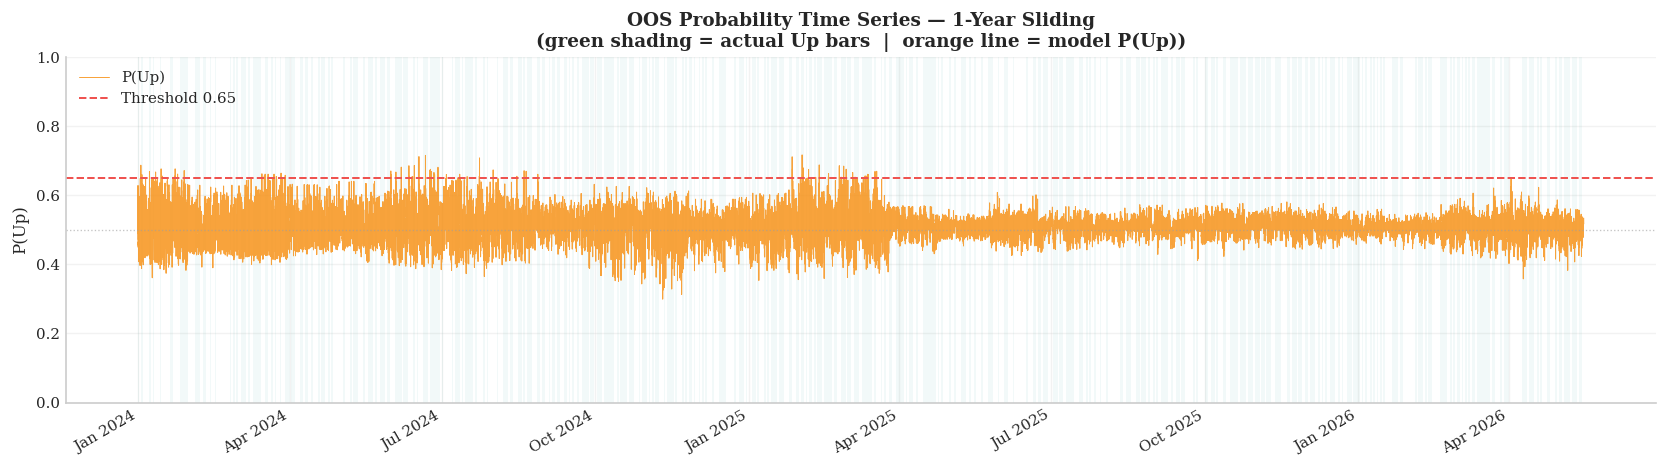

In [47]:
# ── Chart 5: OOS probability time series with actual label shading ────────────
oos_index = oos_df.index
pa    = best_probs_s.values
valid = ~np.isnan(pa)

fig, ax = plt.subplots(figsize=(14, 4))

# Shade background by actual label (green = actual Up)
chunk = 24  # shade in 24-bar chunks for speed
for i in range(0, len(oos_index) - chunk, chunk):
    if y_oos[i] == 1:
        ax.axvspan(oos_index[i], oos_index[min(i + chunk, len(oos_index) - 1)],
                   alpha=0.06, color=GREEN, linewidth=0)

ax.plot(oos_index[valid], pa[valid], color=ACCENT, lw=0.6, alpha=0.85, label='P(Up)')
ax.axhline(DEFAULT_THRESHOLD, color=RED,  lw=1.2, ls='--',
           label=f'Threshold {DEFAULT_THRESHOLD}')
ax.axhline(0.5, color=GREY, lw=0.8, ls=':', alpha=0.6)

ax.set_ylabel('P(Up)'); ax.set_ylim(0, 1)
ax.set_title(
    f'OOS Probability Time Series — {WFO_SCHEMES[BEST_SCHEME]["name"]}\n'
    f'(green shading = actual Up bars  |  orange line = model P(Up))',
    fontweight='bold',
)
ax.legend()
ax.grid(alpha=0.25)
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
fig.tight_layout()
fig.savefig(ARTS_DIR / '07_oos_probability_timeseries.png')
plt.show()

---
## Phase 6 — Meta-Labeling Gatekeeper

Two-model pipeline to prevent fee bleed on low-conviction setups:

```
Primary model  (EMA 12/48 crossover)  →  high-recall raw Long signals
                          ↓
Secondary model (LightGBM, trained on signal bars only)
                → P(trade hits TP before SL)
                          ↓
Gatekeeper: if P < 0.60 → DISCARD (no fee bleed)
            if P ≥ 0.60 → EXECUTE
```

The meta-model is retrained every WFO step (720 bars) with a 12-bar embargo.
Only signal-timestamp feature rows enter training — the model never sees non-signal bars.


In [48]:
from hmats.data.meta_labeling import (
    generate_primary_signals,
    build_meta_labels,
    train_meta_model,
    MetaLabelingBacktester,
)

print('=' * 65)
print('PHASE 6 — META-LABELING GATEKEEPER')
print('=' * 65)

# ── Primary signal stats on OOS period ────────────────────────────────────────
raw_oos = raw_df.loc[oos_df.index].copy()
primary_signals_full = generate_primary_signals(
    raw_oos, fast=META_FAST_EMA, slow=META_SLOW_EMA
)
n_primary = primary_signals_full.sum()
print(f'Primary signal (EMA {META_FAST_EMA}/{META_SLOW_EMA} crossover):')
print(f'  Signals in OOS period : {n_primary}')
print(f'  Signal rate           : {n_primary/len(oos_df):.3%} of OOS bars')


PHASE 6 — META-LABELING GATEKEEPER
Primary signal (EMA 12/48 crossover):
  Signals in OOS period : 11053
  Signal rate           : 53.178% of OOS bars


In [49]:
# ── Walk-forward meta-labeling ──────────────────────────────────────────────
# For each WFO step:
#   1. Generate primary signals on training slice
#   2. Build meta-labels on training slice (TP/SL outcome per signal)
#   3. Train LightGBM on (features at signal times, meta_label)
#   4. Gate test-slice signals through the meta-model

features_df = merged[SELECTED_FEATURES].copy()  # use feature-selected columns
raw_full    = raw_df.reindex(merged.index)

n_oos       = len(oos_df)
meta_eq_arr = np.ones(n_oos)
meta_trades_all = []
cur_meta_eq     = 1.0

step = 0
t_meta = time.time()

while step * STEP_SIZE < n_oos:
    t0 = step * STEP_SIZE
    t1 = min((step + 1) * STEP_SIZE, n_oos)

    first_test_ts  = oos_df.index[t0]
    abs_test_start = merged.index.searchsorted(first_test_ts)
    train_end_abs  = abs_test_start - EMBARGO

    if train_end_abs < 500:
        step += 1
        continue

    tr_raw  = raw_full.iloc[:train_end_abs]
    tr_feat = features_df.iloc[:train_end_abs]

    # Primary signals on train
    prim_tr = generate_primary_signals(tr_raw, fast=META_FAST_EMA, slow=META_SLOW_EMA)
    if prim_tr.sum() < 30:
        step += 1; continue

    # Meta-labels: did each signal hit TP before SL?
    atr_col = merged['atr_14_pct'].iloc[:train_end_abs]
    meta_df_tr = build_meta_labels(
        tr_raw, prim_tr,
        atr_col=atr_col,
        sl_mult=DEFAULT_SL_MULT,
        tp_mult=DEFAULT_TP_MULT,
        max_hold=DEFAULT_MAX_HOLD,
    )
    X_meta = tr_feat.loc[
        tr_feat.index.intersection(meta_df_tr.index)
    ].fillna(0)
    y_meta = meta_df_tr.loc[X_meta.index, 'meta_label']

    if y_meta.nunique() < 2 or len(y_meta) < 30:
        step += 1; continue

    try:
        meta_model = train_meta_model(X_meta, y_meta, val_frac=0.15, verbose=False)
    except Exception:
        step += 1; continue

    # Gate test slice
    test_ohlcv   = raw_full.iloc[abs_test_start : abs_test_start + (t1 - t0)]
    test_feat    = features_df.reindex(test_ohlcv.index)
    prim_test    = generate_primary_signals(
        pd.concat([tr_raw, test_ohlcv]), fast=META_FAST_EMA, slow=META_SLOW_EMA
    ).reindex(test_ohlcv.index)

    bt = MetaLabelingBacktester(
        primary_signals=prim_test,
        meta_model=meta_model,
        feature_cols=SELECTED_FEATURES,
        threshold=META_THRESHOLD,
        sl_mult=DEFAULT_SL_MULT,
        tp_mult=DEFAULT_TP_MULT,
        max_hold=DEFAULT_MAX_HOLD,
        maker_fee=MAKER_FEE,
        taker_fee=SPOT_TAKER_FEE,
    )
    eq_step, tdf_step = bt.run(
        test_ohlcv, test_feat,
        atr_col=merged['atr_14_pct'].reindex(test_ohlcv.index),
    )

    eq_step = eq_step * cur_meta_eq
    cur_meta_eq = eq_step[-1]
    meta_eq_arr[t0:t1] = eq_step
    if len(tdf_step) > 0:
        meta_trades_all.append(tdf_step)

    step += 1

meta_tdf = pd.concat(meta_trades_all) if meta_trades_all else pd.DataFrame()
print(f'Meta-labeling WFO done in {(time.time()-t_meta)/60:.1f} min')
print(f'Total trades executed  : {len(meta_tdf)}')
if len(meta_tdf) > 0:
    wr_meta = (meta_tdf['pnl_pct'] > 0).mean()
    print(f'Win rate               : {wr_meta:.1%}')
    print(f'Total return           : {meta_eq_arr[-1]-1:+.2%}')
    print(f'Sharpe                 : {_sharpe(meta_eq_arr):.3f}')
    print(f'Max DD                 : {_maxdd(meta_eq_arr):.2%}')
    by_reason = dict(meta_tdf['reason'].value_counts())
    print(f'Exit breakdown         : {by_reason}')


Meta-labeling WFO done in 0.3 min
Total trades executed  : 0


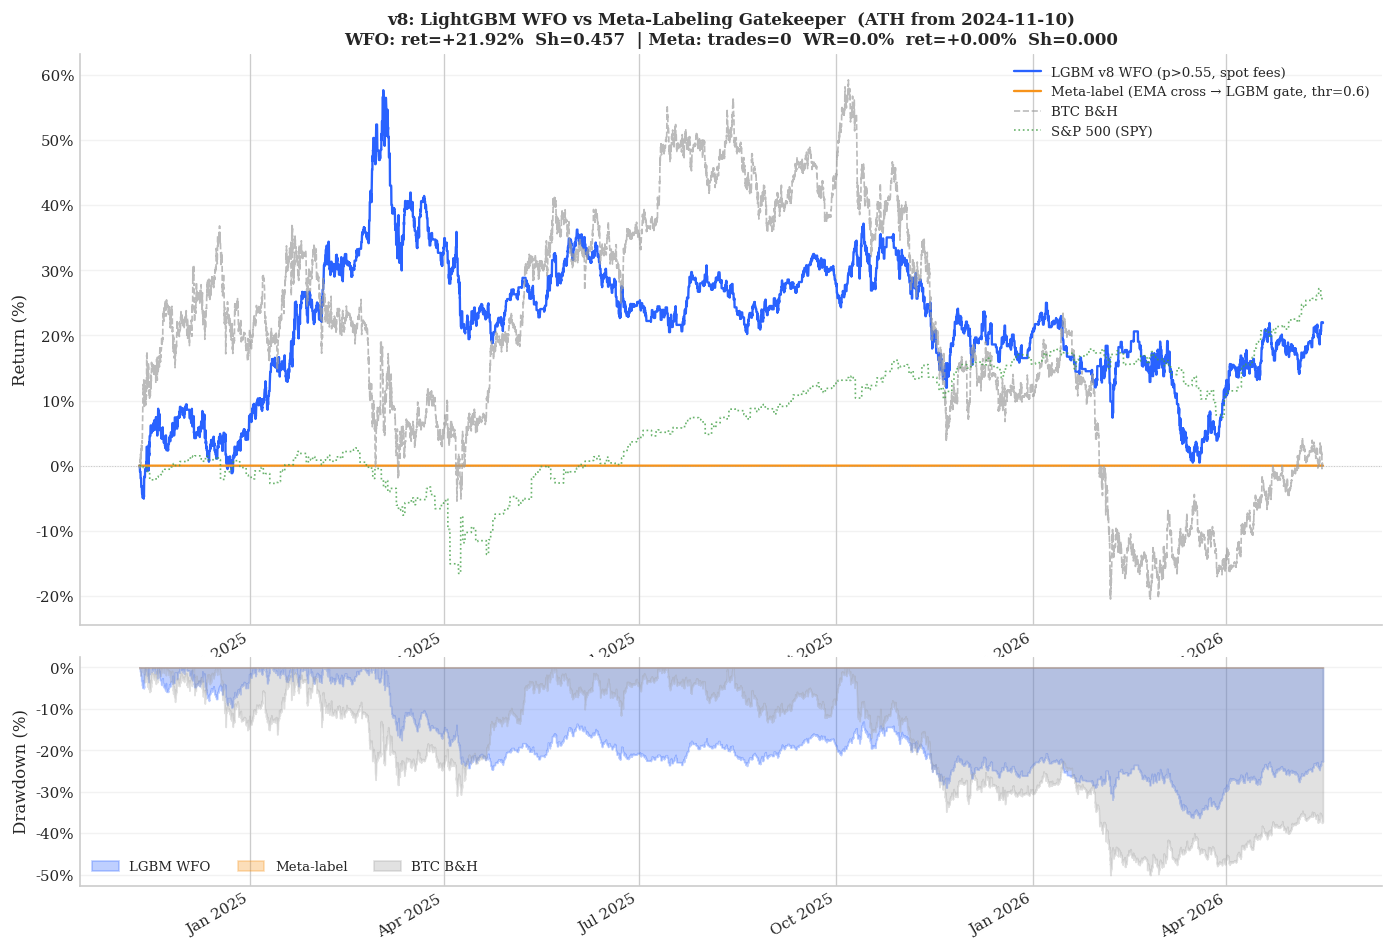

In [50]:
# ── Chart: LightGBM WFO vs Meta-Labeling vs S&P500 (ATH window) ──────────────
from hmats.viz.plots import plot_equity_drawdown, save_fig
import matplotlib.patches as mpatches

_s = _ath_offset
eq_v5_ath   = eq_fee_055[_s:]; eq_v5_ath   = eq_v5_ath   / eq_v5_ath[0]
meta_eq_ath = meta_eq_arr[_s:]; meta_eq_ath = meta_eq_ath / meta_eq_ath[0]

fig, axes = plt.subplots(
    2, 1, figsize=(14, 9),
    gridspec_kw={'height_ratios': [3, 1.2], 'hspace': 0.08}
)

ax = axes[0]
ax.plot(oos_index_ath, (eq_v5_ath - 1) * 100,
        color=BLUE,   lw=1.4, label=f'LGBM v8 WFO (p>0.55, spot fees)')
ax.plot(oos_index_ath, (meta_eq_ath - 1) * 100,
        color=ACCENT, lw=1.4, label=f'Meta-label (EMA cross → LGBM gate, thr={META_THRESHOLD})')
ax.plot(oos_index_ath, bh_pct,
        color=GREY,   lw=1.0, ls='--', alpha=0.7, label='BTC B&H')
if sp500_pct is not None:
    ax.plot(oos_index_ath, sp500_pct,
            color='#43A047', lw=1.0, ls=':', alpha=0.8, label='S&P 500 (SPY)')
ax.axhline(0, color=GREY, lw=0.6, ls=':', alpha=0.5)

wr_meta = (meta_tdf['pnl_pct'] > 0).mean() if len(meta_tdf) > 0 else 0.0
ax.set_title(
    f'v8: LightGBM WFO vs Meta-Labeling Gatekeeper  (ATH from {ATH_START.date()})\n'
    f'WFO: ret={eq_v5_ath[-1]-1:+.2%}  Sh={_sharpe(eq_v5_ath):.3f}  '
    f'| Meta: trades={len(meta_tdf)}  WR={wr_meta:.1%}  '
    f'ret={meta_eq_ath[-1]-1:+.2%}  Sh={_sharpe(meta_eq_ath):.3f}',
    fontsize=10, fontweight='bold',
)
ax.set_ylabel('Return (%)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.25)

ax_dd = axes[1]
for eq_arr, color, lbl in [
    (eq_v5_ath,   BLUE,   'LGBM WFO'),
    (meta_eq_ath, ACCENT, 'Meta-label'),
    (bh_pct,      GREY,   'BTC B&H'),
]:
    if eq_arr.ndim == 1 and len(eq_arr) > 0:
        if lbl == 'BTC B&H':
            # bh_pct is already % — convert to multiplier for drawdown calc
            eq_mult = eq_arr / 100 + 1
        else:
            eq_mult = eq_arr
        pk = np.maximum.accumulate(eq_mult)
        ax_dd.fill_between(oos_index_ath, (eq_mult - pk) / (pk + 1e-12) * 100, 0,
                           color=color, alpha=0.30, label=lbl)

ax_dd.set_ylabel('Drawdown (%)')
ax_dd.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))
ax_dd.legend(fontsize=8, ncol=3)
ax_dd.grid(axis='y', alpha=0.25)

for ax in axes:
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,4,7,10]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

save_fig(fig, ARTS_DIR / '01_wfo_vs_meta.png')
plt.show()


In [51]:
# ── Meta-model: signal probability distribution + threshold sensitivity ────────
# Collect all meta-model scores from the last WFO step (for inspection)
if len(meta_trades_all) > 0 and len(meta_tdf) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Trade PnL distribution
    ax = axes[0]
    ax.hist(meta_tdf[meta_tdf['pnl_pct'] > 0]['pnl_pct'],
            bins=25, color=GREEN, alpha=0.7, label='Win', density=True)
    ax.hist(meta_tdf[meta_tdf['pnl_pct'] <= 0]['pnl_pct'],
            bins=25, color=RED,   alpha=0.7, label='Loss', density=True)
    ax.axvline(0, color=GREY, lw=1, ls='--')
    avg_pnl = meta_tdf['pnl_pct'].mean()
    ax.set_xlabel('Net PnL per trade (% of equity)')
    ax.set_ylabel('Density')
    ax.set_title(f'Meta-Labeled Trade PnL Distribution\n'
                 f'n={len(meta_tdf)}  avg={avg_pnl:+.3f}%  WR={wr_meta:.1%}',
                 fontweight='bold')
    ax.legend()

    # Exit reason breakdown
    ax = axes[1]
    by_r = meta_tdf.groupby('reason')['pnl_pct'].agg(['count','mean'])
    colors_r = {'tp': GREEN, 'sl': RED, 'timeout': GREY, 'eod': BLUE}
    bars = ax.bar(by_r.index, by_r['count'],
                 color=[colors_r.get(r, ACCENT) for r in by_r.index], alpha=0.85)
    for bar, (_, row) in zip(bars, by_r.iterrows()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'avg={row["mean"]:+.2f}%', ha='center', va='bottom', fontsize=9)
    ax.set_xlabel('Exit reason')
    ax.set_ylabel('Trade count')
    ax.set_title('Exit Reason Breakdown\n(meta-labeling gatekeeper trades)',
                 fontweight='bold')

    fig.suptitle('Meta-Labeling Trade Analysis — LGBM v8', fontweight='bold')
    fig.tight_layout()
    fig.savefig(ARTS_DIR / '02_meta_trade_analysis.png')
    plt.show()


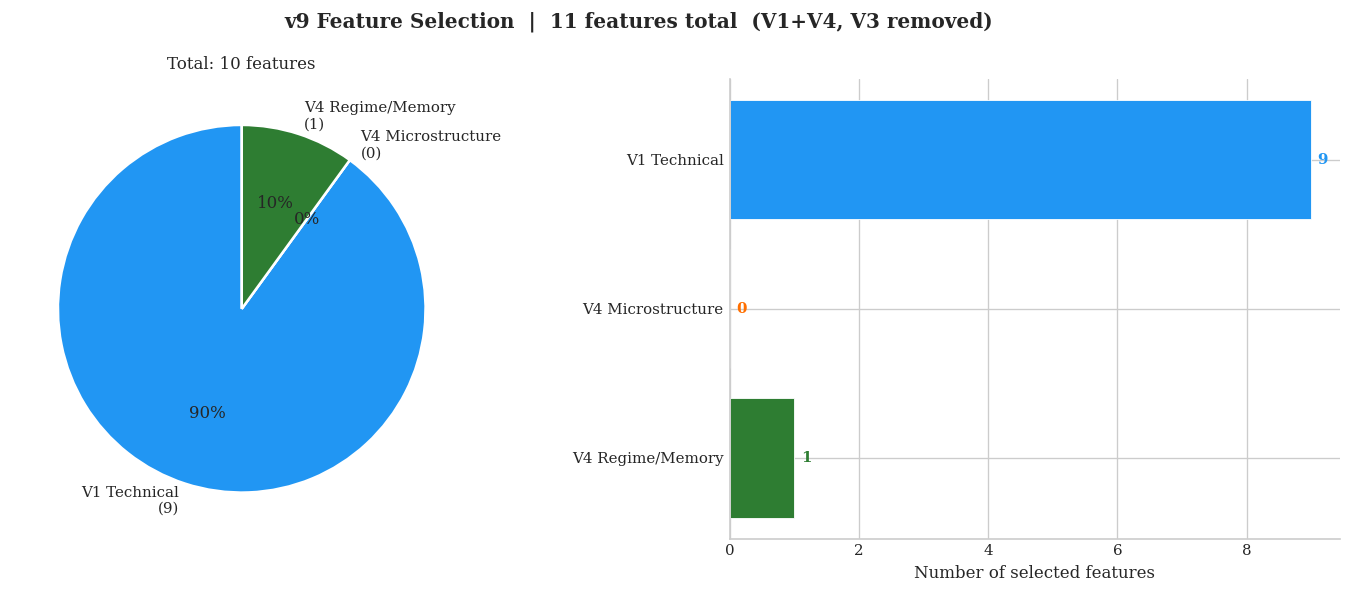

In [52]:
# ── Chart: V4 feature group contribution to the selected set ─────────────────
from hmats.viz.plots import plot_feature_group_pie, save_fig

fig = plot_feature_group_pie({
    'V1 Technical':         v1_selected,
    'V4 Microstructure':    [f for f in v4_selected if any(
                                f.startswith(p) for p in ('tfi_','avg_trade','true_vwap','taker_','mark_','index_'))],
    'V4 Regime/Memory':     [f for f in v4_selected if any(
                                f.startswith(p) for p in ('fracdiff','hurst','adf_','bb_width','sideways'))],
})
fig.suptitle(f'v9 Feature Selection  |  {len(SELECTED_FEATURES)} features total  (V1+V4, V3 removed)',
             fontweight='bold')
from hmats.viz.plots import save_fig
save_fig(fig, ARTS_DIR / '03_feature_groups.png')
plt.show()


In [53]:
# ── Save results.json ─────────────────────────────────────────────────────────
def _bt(eq, tdf, label):
    wr = float((tdf['pnl_pct'] > 0).mean()) if len(tdf) > 0 else 0.0
    return {'label': label, 'n_trades': len(tdf), 'win_rate': wr,
            'total_ret': float(eq[-1]-1), 'sharpe': float(_sharpe(eq)),
            'maxdd': float(_maxdd(eq))}

results = {
    'notebook': '02_lgbm_omni_0fee_v9',
    'version': 'v9',
    'created': pd.Timestamp.now().isoformat(),
    'ath_start': str(ATH_START.date()),
    'feature_pool': {
        'v1': len(V1_FEATURE_COLS),
        'v4': len(V4_FEATURE_COLS),
        'total': len(ALL_FEATURE_COLS),
        'note': 'V3 external features removed',
    },
    'selected_features': SELECTED_FEATURES,
    'v4_survived': v4_selected,
    'best_scheme': BEST_SCHEME,
    'best_params': {k: (int(v) if isinstance(v, (np.integer,int)) else float(v))
                    for k, v in BEST_PARAMS.items()},
    'lgbm_wfo_055':  _bt(eq_fee_055, tdf_fee_055, 'lgbm_wfo_p055'),
    'lgbm_wfo_060':  _bt(eq_fee_060, tdf_fee_060, 'lgbm_wfo_p060'),
    'meta_labeling': _bt(meta_eq_arr, meta_tdf, f'meta_thr{META_THRESHOLD}'),
    'meta_config': {
        'fast_ema': META_FAST_EMA, 'slow_ema': META_SLOW_EMA,
        'threshold': META_THRESHOLD,
        'sl_mult': DEFAULT_SL_MULT, 'tp_mult': DEFAULT_TP_MULT,
    },
}
with open(ARTS_DIR / 'results.json', 'w') as f:
    json.dump(results, f, indent=2, default=str)
print('Saved results.json')

print('\n── Summary ──────────────────────────────────────────────')
print(f'ATH start (display window)  : {ATH_START.date()}')
print(f'V4 features in final set    : {v4_selected}')
print(f'LGBM WFO   (p>0.55)        : ret={eq_fee_055[-1]-1:+.2%}  Sh={_sharpe(eq_fee_055):.3f}')
print(f'Meta-label (thr={META_THRESHOLD})    : ret={meta_eq_arr[-1]-1:+.2%}  Sh={_sharpe(meta_eq_arr):.3f}  n={len(meta_tdf)}')
print(f'BTC B&H ATH-window          : ret={bh_pct[-1]:+.1f}%')
if sp500_pct is not None:
    print(f'S&P500 ATH-window           : ret={sp500_pct.iloc[-1]:+.1f}%')


NameError: name 'tdf_fee_060' is not defined